# Load data and functions

In [408]:
import numpy as np
import os

# IMPORTANT: Directory that contains all functions+files downloaded from the repository/box
functions_dir = '/Users/alextz/Documents/github_first_study/Sample_data/'
os.chdir(functions_dir)
subjects = np.arange(0,1) 
num_subs = 1

import pickle
import glob
from scipy.stats import t
#from nipy.modalities.fmri.hemodynamic_models import spm_hrf
import multiprocessing as mp
import h5py
import scipy.stats as stats
from scipy import signal
import scipy.io as spio
from numpy import arange
from pandas import read_csv
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedKFold
import matplotlib.pyplot as plt
import time
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import sklearn.preprocessing as skp
from wbplot import pscalar # pscalar is for values for each parcel, dscalar is for values for each vertex, https://github.com/jbburt/wbplot
from wbplot import constants
import matplotlib.image as mpimg
import matplotlib.colors as clrs
from matplotlib import colorbar
from os.path import join
import sys
import scipy.io as spio
import nibabel as nib
from scipy import signal
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import shapiro, pearsonr, spearmanr
from wbplot import dscalar
from scipy.stats import zscore
from datetime import datetime, timedelta
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_rel
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
import networkx as nx
from joblib import Parallel, delayed
from scipy.linalg import expm
from sklearn.cluster import KMeans
from matplotlib import colormaps as cm
import subprocess
from astropy.stats import circcorrcoef
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon


sys.path.append(functions_dir)
# import specific functions from files
import graph_functions
import helper_functions
import plotting_functions
import V1_initiated_model
import stats_functions
import RSA_functions
import actflow_multilayer_retinotopic_basic_functions as act_functions

# all subjects for this project (Apr 2025)
subj_here = ['100610', '102311', '102816', '104416', '105923', '108323', '109123', '111514', '114823', '115017', '115825', '116726', 
             '118225', '125525', '126426', '467351', '525541', '825048', '826353', '833249', '859671', '861456', '871762', '872764', 
             '878776', '878877', '898176', '899885', '901139', '901442', '905147', '910241', '926862', '927359', '942658', '943862', 
             '958976', '966975', '971160', '995174', '128935', '131722', '137128', '140117', '144226', '283543', '318637', '320826', 
             '330324', '346137', '541943', '547046', '562345', '572045', '573249', '581450', '601127', '617748', '627549', '638049', 
             '644246', '654552', '671855', '680957', '690152', '706040', '724446', '725751', '732243', '751550', '757764', '765864', 
             '770352', '771354', '782561', '783462', '789373', '814649', '818859', '951457'] # this is the full dataset, 80 subs. 0-39 (included) is group A,
            # 40-79 (included) is group B (control)

dlabelfile = functions_dir + 'CortexSubcortex_ColeAnticevic_NetPartition_wSubcorGSR_parcels_LR.dlabel.nii' # new dlabels file
nVertices = 59412 # cortex only
dlabels = np.squeeze(nib.load(dlabelfile).get_fdata()) # whole brain, 91282 vertices, 1 based not 0 based
dlabels = dlabels[:nVertices]

nParcels = 360
selected_parcels = [1, 4, 5, 6, 181, 184, 185, 186]
selected_parcels_output = [4, 5, 6, 184, 185, 186]
parcel_names = {
    1: 'Left V1',
    4: 'Left V2',
    5: 'Left V3',
    6: 'Left V4',
    181: 'Right V1',
    184: 'Right V2',
    185: 'Right V3',
    186: 'Right V4'
}

names = ['V2', 'V3', 'V4']
ordered_names = [parcel_names[selected_parcels[i]] for i in range(len(selected_parcels))]
parcel_names_list = [parcel_names[label] for label in selected_parcels]
dlabels_subset = helper_functions.dlabels_subset_creation(dlabels, selected_parcels)
dlabels_subset_output = helper_functions.dlabels_subset_creation(dlabels, selected_parcels_output)
parcel_indices = helper_functions.map_vertices_to_parcels(dlabels_subset, selected_parcels)

# set font sizes to be consistent
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans'],
    # for math text (if you use TeX-like math in labels)
    'mathtext.fontset': 'stix',
})


In [5]:
# necessary library to run Glasso regularization at the parcel level
pip install gglasso


831

# Functions

In [410]:


def draw_model_steps_boxplot(
    r2_data,          # ndarray, shape (n_models, n_subjects, n_steps)
    model_names,      # list of str, length = n_models (1 or 2)
    step_names,       # list of str, length = n_steps
    p_corr_by_step=None,  # list of corrected p-values, length = n_steps (only for 2 models)
    metric_name='R²',
    title='Model Comparison Across Steps',
    box_to_anchor=(1.4, 1),
    showmeans=True,
    figsize=(12,6),
    base_fs=12,
    save_path=None
):
    """
    One plot: for each step, boxplots per model (1 or 2 models),
    with subject points and significance bracket per step if two models.
    """
    n_models, n_subj, n_steps = r2_data.shape
    assert n_models in (1, 2), "Only supports 1 or 2 models"
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.despine(ax=ax)

    xs = np.arange(n_steps)
    width = 0.3

    # Compute positions
    if n_models == 2:
        positions = [xs - width/2, xs + width/2]
    else:
        positions = [xs]  # single model

    # 1) Boxplots
    bps = []
    colors = ['C0', 'C1']
    for m in range(n_models):
        data_m = [r2_data[m, :, step] for step in range(n_steps)]
        pos = positions[m]
        bp = ax.boxplot(
            data_m,
            positions=pos,
            widths=width if n_models==2 else width*1.2,
            patch_artist=True,
            boxprops={'facecolor': colors[m], 'alpha': 0.6},
            showmeans=showmeans,
            medianprops={'color':'orange', 'linewidth':2},
            meanprops={'marker':'^','markerfacecolor':'green',
                       'markeredgecolor':'black','markersize':8},
            labels=None,
            showfliers=False
        )
        bps.append(bp)

    # 2) Overlay subject points
    for m in range(n_models):
        for step in range(n_steps):
            vals = r2_data[m, :, step]
            xpos = positions[m][step]
            jitter = width/8 if n_models==2 else width/4
            xs_jit = np.random.normal(loc=xpos, scale=jitter, size=n_subj)
            ax.scatter(xs_jit, vals, color='gray', alpha=0.7, s=20, zorder=3)

    # 3) Step labels + x-axis label
    ax.set_xticks(xs)
    ax.set_xticklabels(step_names, fontsize=base_fs)
    ax.set_xlabel('Steps', fontsize=base_fs)

    # 4) Legend (with ref-line entry)
    handles, labels = [], []

    # model patches only when >1 model
    if n_models == 2:
        handles.extend([
            Line2D([], [], marker='s', color='C0', linestyle='', label=model_names[0]),
            Line2D([], [], marker='s', color='C1', linestyle='', label=model_names[1])
        ])

    # always show median
    handles.append(Line2D([], [], color='orange', linewidth=2, label='Median'))

    if showmeans:
        handles.append(Line2D([], [], marker='^', color='green',
                              markeredgecolor='black', linestyle='', label='Mean'))
    
    
    # ─── add the reference line to legend ───
    handles.append(Line2D([], [], linestyle='--', color='gray', linewidth=1.5, label='Full model $R^2$, last step'))
    
    
    # extract labels and draw
    labels = [h.get_label() for h in handles]
    ax.legend(handles, labels,
              frameon=False,
              fontsize=base_fs-8,
              loc='upper right',
              bbox_to_anchor=box_to_anchor)

    # 5) Significance brackets per step (only for 2 models)
    if n_models == 2 and p_corr_by_step:
        y_min, y_max = np.nanmin(r2_data), np.nanmax(r2_data)
        yrange = y_max - y_min
        offset = 0.05 * yrange
        h = 0.02 * yrange

        for step, p_corr in enumerate(p_corr_by_step):
            if p_corr < 0.05:
                x1 = positions[0][step]
                x2 = positions[1][step]
                if p_corr < 0.001:
                    stars = '***'
                elif p_corr < 0.01:
                    stars = '**'
                else:
                    stars = '*'
                #y = y_max + offset * (step + 1)
                y = y_max + offset
                ax.plot([x1, x1, x2, x2],
                        [y, y+h, y+h, y],
                        lw=1.5, color='black')
                ax.text((x1+x2)/2, y+h, stars,
                        ha='center', va='bottom',
                        fontsize=base_fs-4)

        ax.set_ylim(top=y_max + offset*(n_steps+2))

    # 6) Labels and layout
    ax.set_title(title, fontsize=base_fs+1)
    ax.set_ylabel(metric_name, fontsize=base_fs)
    ax.tick_params(axis='y', labelsize=base_fs)
    
    
    # ─── NEW: add horizontal dashed line + label ───
    y_ref = 0.4113
    ax.axhline(y=y_ref, linestyle='--', color='gray', linewidth=1.5)
    # place label at the right end of the line, slightly above it
    
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def compute_model_statistics_wilcoxon(r2_data, model_names, alpha=0.05):
    """
    Paired Wilcoxon tests for two models across steps.

    Parameters
    ----------
    r2_data : ndarray, shape (n_models, n_subjects, n_steps)
    model_names : list of str, length = n_models (here n_models=2)
    alpha : float
        familywise alpha

    Returns
    -------
    p_corr_by_step : list of floats, length = n_steps
        Bonferroni-corrected p-value for the comparison at each step.
    """
    n_models, n_subj, n_steps = r2_data.shape
    assert n_models == 2, "This version assumes exactly two models"
    m = 6  # six comparisons in total, one for each step

    p_corr_by_step = []
    for step in range(n_steps):
        a = r2_data[0, :, step]
        b = r2_data[1, :, step]
        _, p_raw = wilcoxon(a, b, zero_method='wilcox')
        p_corr = min(p_raw * m, 1.0)
        p_corr_by_step.append(p_corr)

    return p_corr_by_step

def draw_hemisphere_boxplot(
    metric, metric_name, names, title, box_to_anchor=(1.35,1.00),
    save_path=None, figsize=(12,12),
    base_fs=12, sig_pairs=None, showmeans=True
):
    """
    Draws a polished hemisphere boxplot using Seaborn’s boxplot,
    with manual gray dots for subjects and significance brackets.
    """
    # If only one region, make names a tuple to avoid grouping issues
    if len(names) == 1:
        names = (names[0],)

    # Plain white style
    sns.set_style("white")
    fig, ax = plt.subplots(figsize=figsize)
    sns.despine(ax=ax)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Color mapping for boxes
    set2 = sns.color_palette("Set2", n_colors=4)
    if metric.shape[1] == 4:
        cmap = {names[0]: set2[3], names[1]: set2[0],
                names[2]: set2[1], names[3]: set2[2]}
    elif metric.shape[1] == 3:
        cmap = {names[0]: set2[0], names[1]: set2[1], names[2]: set2[2]}
    elif metric.shape[1] == 2:
        cmap = {names[0]: set2[1], names[1]: set2[2]}
    else:
        cmap = {}
    palette = [cmap.get(r, "lightblue") for r in names]

    # Boxplot
    sns.boxplot(data=metric, palette=palette, ax=ax,
                showfliers=False,
                medianprops={'color':'orange','linewidth':2})
    ax.grid(False)

    # Manual scatter for subject points (consistent gray)
    n_regions = metric.shape[1]
    for i in range(n_regions):
        vals = metric[:, i]
        # jitter around x = i
        xs = np.random.normal(loc=i, scale=0.05, size=len(vals))
        ax.scatter(xs, vals, color='gray', alpha=0.7, s=20, zorder=3)

    # Legend for mean & median
    xs_centers = np.arange(metric.shape[1])
    handles = []
    if showmeans:
        means = np.nanmean(metric, axis=0)
        ax.scatter(xs_centers, means, marker="^", color="green",
                   edgecolors="black", s=50, label="Mean", zorder=4)
        handles.append(Line2D([], [], marker="^", color="green",
                              markeredgecolor="black", linestyle="",
                              label="Mean"))
    # median line in legend
    handles.append(Line2D([], [], color="orange", linewidth=2, label="Median"))
    ax.legend(handles=handles, frameon=False,
              loc="upper right", bbox_to_anchor=box_to_anchor,
              fontsize=base_fs-7)

    # Significance brackets
        # Significance brackets & stars
    if sig_pairs:
        y_min, y_max = np.nanmin(metric), np.nanmax(metric)
        yrange = y_max - y_min
        offset, h = 0.05 * yrange, 0.02 * yrange

        for idx, (r1, r2, p_val) in enumerate(sig_pairs):
            # decide how many stars
            if p_val < 0.001:
                stars = '***'
            elif p_val < 0.01:
                stars = '**'
            elif p_val < 0.05:
                stars = '*'
            else:
                continue  # no annotation if p ≥ 0.05

            # vertical position for this annotation
            y = y_max + offset * (idx + 1)

            if r1 == r2:
                # single‐box significance: just put stars above box r1/r2
                x = names.index(r1)
                ax.text(x, y, stars,
                        ha="center", va="bottom",
                        fontsize=base_fs-4)
            else:
                # existing bracket logic for pairs
                x1, x2 = names.index(r1), names.index(r2)
                ax.plot([x1, x1, x2, x2],
                        [y, y+h, y+h, y],
                        lw=1.5, color="black")
                ax.text((x1 + x2) / 2, y + h, stars,
                        ha="center", va="bottom",
                        fontsize=base_fs-4)

        # extend the top of the plot to fit all annotations
        ax.set_ylim(top=y_max + offset * (len(sig_pairs) + 2))

    # Final labels
    ax.set_xticklabels(names, fontsize=base_fs, rotation=0)
    ax.set_title(title, fontsize=base_fs+2)
    ax.set_ylabel(metric_name, fontsize=base_fs)
    ax.tick_params(axis='y', labelsize=base_fs)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

import numpy as np
from scipy.stats import wilcoxon
from math import sqrt

def compute_model_statistics_wilcoxon_with_r(
    r2_data,
    model_names,
    alpha=0.05,
    zero_method="wilcox",
    correction=False,
    alternative="two-sided",
    method="asymptotic",
):
    """
    Paired Wilcoxon signed-rank tests (model 0 vs model 1) across steps,
    with Bonferroni correction and effect size r = z / sqrt(N).

    Parameters
    ----------
    r2_data : ndarray, shape (2, n_subjects, n_steps)
    model_names : list[str], length 2
    alpha : float
        familywise alpha
    zero_method : {'wilcox','pratt','zsplit'}
    correction : bool
        continuity correction (passed to scipy.stats.wilcoxon)
    alternative : {'two-sided','greater','less'}
    method : {'exact','asymptotic','auto'}
        We set default to 'asymptotic' to obtain z-statistic when available.

    Returns
    -------
    step_results : list of dict, length n_steps
        Each dict includes W, z, r, p_raw, p_bonf, N used, etc.
    """
    r2_data = np.asarray(r2_data, dtype=float)
    n_models, n_subj, n_steps = r2_data.shape
    assert n_models == 2, "This version assumes exactly two models"

    m = n_steps  # Bonferroni across steps

    step_results = []
    for step in range(n_steps):
        a = r2_data[0, :, step]
        b = r2_data[1, :, step]

        # pairwise NaN removal
        mask = ~np.isnan(a) & ~np.isnan(b)
        a_ = a[mask]
        b_ = b[mask]

        # N used depends on zero_method (for 'wilcox', zero diffs are dropped)
        d = a_ - b_
        if zero_method == "wilcox":
            d_nz = d[d != 0]
            N_used = int(d_nz.size)
        else:
            # pratt / zsplit handle zeros differently; keep them in N as "paired obs"
            N_used = int(d.size)

        # Run Wilcoxon (prefer method=... API; fall back if SciPy is older)
        try:
            res = wilcoxon(
                a_, b_,
                zero_method=zero_method,
                correction=correction,
                alternative=alternative,
                method=method
            )
        except TypeError:
            # Older SciPy uses 'mode' instead of 'method'
            # 'approx' ~ asymptotic; 'auto' chooses based on n/ties
            mode = "approx" if method == "asymptotic" else "auto"
            res = wilcoxon(
                a_, b_,
                zero_method=zero_method,
                correction=correction,
                alternative=alternative,
                mode=mode
            )

        W = float(res.statistic) if np.isfinite(res.statistic) else np.nan
        p_raw = float(res.pvalue) if np.isfinite(res.pvalue) else np.nan
        p_bonf = min(p_raw * m, 1.0) if np.isfinite(p_raw) else np.nan

        # z-statistic: available in newer SciPy when using method='asymptotic'
        z = np.nan
        if hasattr(res, "zstatistic") and res.zstatistic is not None and np.isfinite(res.zstatistic):
            z = float(res.zstatistic)

        # Effect size r = z / sqrt(N_used)  (only meaningful if z is available and N_used>0)
        r_eff = np.nan
        if np.isfinite(z) and N_used > 0:
            r_eff = z / sqrt(N_used)

        step_results.append({
            "model_a": model_names[0],
            "model_b": model_names[1],
            "step": step,
            "n_pairs_non_nan": int(mask.sum()),
            "N_used_for_r": N_used,
            "W": W,
            "z": z,
            "r_effect": r_eff,
            "p_raw": p_raw,
            "p_bonf": p_bonf,
            "median_diff": float(np.median(d)) if d.size else np.nan,
            "mean_diff": float(np.mean(d)) if d.size else np.nan,
            "alternative": alternative,
            "zero_method": zero_method,
        })

    # If you still want just corrected p-values like your original:
    # p_corr_by_step = [r["p_bonf"] for r in step_results]
    return step_results


In [412]:
lv1_indices = np.where(dlabels==1)[0]
lv2_indices = np.where(dlabels==4)[0]
lv3_indices = np.where(dlabels==5)[0]
lv4_indices = np.where(dlabels==6)[0]
rv1_indices = np.where(dlabels==181)[0]
rv2_indices = np.where(dlabels==184)[0]
rv3_indices = np.where(dlabels==185)[0]
rv4_indices = np.where(dlabels==186)[0]
lm1_indices = np.where(dlabels==8)[0]

lv1_indices_subset = np.where(dlabels_subset==1)[0]
lv2_indices_subset = np.where(dlabels_subset==4)[0]
lv3_indices_subset = np.where(dlabels_subset==5)[0]
lv4_indices_subset = np.where(dlabels_subset==6)[0]
rv1_indices_subset = np.where(dlabels_subset==181)[0]
rv2_indices_subset = np.where(dlabels_subset==184)[0]
rv3_indices_subset = np.where(dlabels_subset==185)[0]
rv4_indices_subset = np.where(dlabels_subset==186)[0]

lv1_indices_subset_output = np.where(dlabels_subset_output==1)[0]
lv2_indices_subset_output = np.where(dlabels_subset_output==4)[0]
lv3_indices_subset_output = np.where(dlabels_subset_output==5)[0]
lv4_indices_subset_output = np.where(dlabels_subset_output==6)[0]
rv1_indices_subset_output = np.where(dlabels_subset_output==181)[0]
rv2_indices_subset_output = np.where(dlabels_subset_output==184)[0]
rv3_indices_subset_output = np.where(dlabels_subset_output==185)[0]
rv4_indices_subset_output = np.where(dlabels_subset_output==186)[0]

runs_to_use = [0,1,2,3,4]
# last two runs which are the bar, are identical. therefore we can average the whole runs and 
# keep all the time points
T = np.arange(22, 278)
regions = {
    'LV1': lv1_indices,
    'LV2': lv2_indices,
    'LV3': lv3_indices,
    'LV4': lv4_indices,
    'RV1': rv1_indices,
    'RV2': rv2_indices,
    'RV3': rv3_indices,
    'RV4': rv4_indices
}

regions_subset = {
    'LV1': lv1_indices_subset,
    'LV2': lv2_indices_subset,
    'LV3': lv3_indices_subset,
    'LV4': lv4_indices_subset,
    'RV1': rv1_indices_subset,
    'RV2': rv2_indices_subset,
    'RV3': rv3_indices_subset,
    'RV4': rv4_indices_subset
}

regions_subset_output = {
    'LV1': lv1_indices_subset_output,
    'LV2': lv2_indices_subset_output,
    'LV3': lv3_indices_subset_output,
    'LV4': lv4_indices_subset_output,
    'RV1': rv1_indices_subset_output,
    'RV2': rv2_indices_subset_output,
    'RV3': rv3_indices_subset_output,
    'RV4': rv4_indices_subset_output
}

regions_names = list(parcel_names.values())


# Load data

In [414]:
# load retinotopy data
data_all = {}
for subj in subjects:
     data_all[subj] = act_functions.load_ret(subj, functions_dir)
        

pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


# Estimate and load FC at the parcel level (Glasso)

In [416]:

from graphicalLassoCV import graphicalLassoCV
from loadRest2 import loadRestResiduals
from loadRest2 import parcelate_data

start_time = time.time()
for sub in subjects:
    print('Running sub = ', sub)
    data_full, data_conc_cortex, data_conc_subcortex = loadRestResiduals(sub, dlabels, functions_dir, cortex_only=False)
    rest_vertexavg_allruns = np.zeros((nParcels,data_conc_cortex.shape[1]))
    subj_id = subj_here[sub]

    data_conc_cortex_norm = stats.zscore(data_conc_cortex,axis=1)
    data_conc_subcortex = stats.zscore(data_conc_subcortex,axis=1)
    data_wsubcortex = np.concatenate([data_conc_cortex_norm, data_conc_subcortex], axis=0)

    rest_vertexavg_allruns = parcelate_data(data_conc_cortex_norm, dlabels)
    
    L1s = np.logspace(-7, 2, 20)
    data_cortex_only_ICA_parcels = rest_vertexavg_allruns
    conn_matrix , cvResults = graphicalLassoCV(data_cortex_only_ICA_parcels,L1s=L1s,kFolds=10,optMethod='R2',saveFiles=0,outDir='')
    with open('glasso_scores_parcels_L1s_ICA_' + subj_id + '.pkl', 'wb') as f:
        pickle.dump(cvResults, f)

end_time = time.time()
print("Time taken = ", end_time-start_time)
        

Running sub =  0


FileNotFoundError: No such file or no access: 'rfMRI_REST1_7T_PA_Atlas_MSMAll_hp2000_clean.dtseries.nii'

In [19]:
conn_matrix[0,0:10]

array([ 0.00000000e+00, -0.00000000e+00, -2.76831529e-02,  2.27205947e-01,
        8.36149788e-02,  7.57497216e-02,  1.63755933e-05, -0.00000000e+00,
        9.03681702e-03,  1.03957410e-02])

In [394]:
# load all glasso FC in a single matrix
glasso_all_subs = np.load('glasso_all_subs_A.npy')


## Plot FC matrix

In [398]:
glasso_avg_subs = np.mean(glasso_all_subs, axis=0)

On-diagonal pops out in the _ordered matrix, highlighting network communities:


<Figure size 1000x500 with 0 Axes>

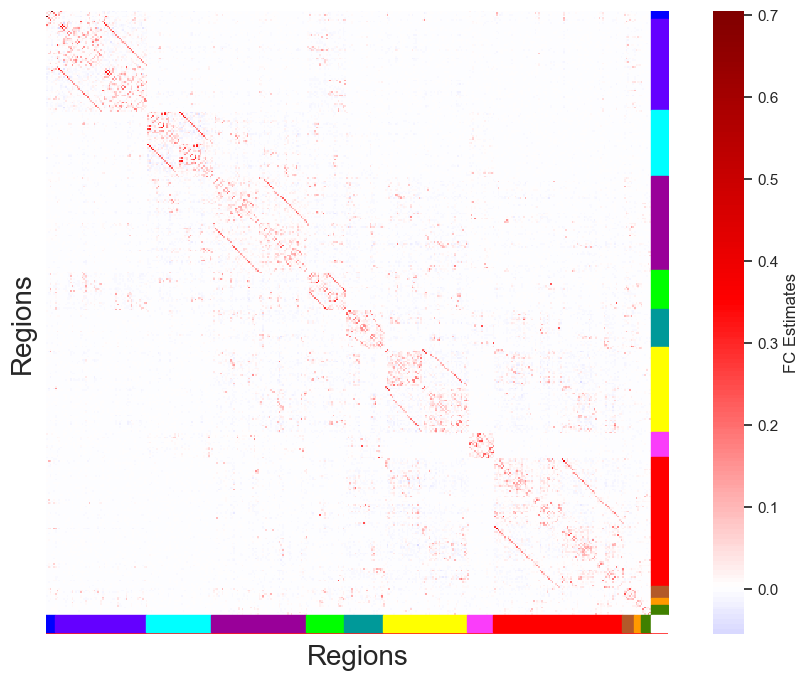

In [404]:
plt.rcParams['image.interpolation'] = 'none'
plt.rcParams['figure.figsize'] = 6,4
plt.rcParams.update({'font.size': 16})
plt.rcParams['image.aspect'] = 'equal'
plt.rcParams['image.cmap'] = 'seismic'
import addNetColors_Seaborn

# use cortical parcellation
networkdef = np.loadtxt('cortex_parcel_network_assignments.txt') 
networkorder = np.asarray(sorted(range(len(networkdef)), key=lambda k: networkdef[k])) # derive networkorder i.e. specific indices to reorder matrix into network communities
orderedNetworks = ['VIS1','VIS2','SMN','CON','DAN','LAN','FPN','AUD','DMN','PMM','VMM','OA'] # order of networks i.e. VIS1 network first -> OA network last
networkpalette = ['royalblue','slateblue','paleturquoise','darkorchid','limegreen',
                  'lightseagreen','yellow','orchid','r','peru','orange','olivedrab'] # canonical colors for each network
networkpalette = np.asarray(networkpalette)
# confine fcmat to cortex (first 360 regions), then reorganize into networks
fcmat_cort_ordered=glasso_avg_subs[networkorder,:][:,networkorder]
# fig=actflow.tools.addNetColors_Seaborn(fcmat_cort)
print('On-diagonal pops out in the _ordered matrix, highlighting network communities:')
plt.figure(figsize = (10,5))
fig=addNetColors_Seaborn.addNetColors_Seaborn(fcmat_cort_ordered)

plt.close(fig)

# Load GC-PCR results

In [221]:
# modify this to load the second half of subjects
connectivity_matrix_all_subs = helper_functions.load_conn_matrix_all_subs(subjects, functions_dir, selected_parcels, dlabels, dilation=False)


In [223]:
connectivity_matrix_all_subs.shape

(1, 4183, 4183)

# Percentage of connections

In [14]:
# check percentage of direct connections in early visual areas 
# change sources to find all connection percentages 
# conn_matrices: list of 40 NumPy arrays, each shape (360,360)
# region_indices: dict mapping names → indices
conn_matrices = glasso_all_subs
region_indices = {
    'lV1': 0, 'lV2': 3, 'lV3': 4, 'lV4': 5,
    'rV1': 180, 'rV2': 183, 'rV3': 184, 'rV4': 185
}

sources = ['lV3','rV3']
targets = [r for r in region_indices if r not in sources]

existence_percents = []
for target in targets:
    idx_t = region_indices[target]
    exists = [
        (mat[region_indices[sources[0]], idx_t] != 0) or
        (mat[region_indices[sources[1]], idx_t] != 0)
        for mat in conn_matrices
    ]
    pct = np.mean(exists) * 100
    existence_percents.append(pct)

# put into a DataFrame
df = pd.DataFrame({
    'Target_Region': targets,
    f'Existence_%_from_{sources}': existence_percents
})
print(df)

  Target_Region  Existence_%_from_['lV3', 'rV3']
0           lV1                             67.5
1           lV2                            100.0
2           lV4                            100.0
3           rV1                             77.5
4           rV2                            100.0
5           rV4                            100.0


# Connectivity-based hierarchy

## Communicability based on Glasso (parcel-wise)

In [329]:
# communicability based on Glasso
glasso_all_subs = np.load('glasso_all_subs_A.npy')
vis_parcels = [0, 3, 4, 5, 180, 183, 184, 185] # python 0-based
glasso_vis = np.zeros((num_subs, 8, 8))
for sub in range(num_subs):
    for i,target in enumerate(vis_parcels):
        for j,source in enumerate(vis_parcels):
            glasso_vis[sub][i,j] = glasso_all_subs[sub][target,source]
connectivity_matrix_all_subs = glasso_vis 

# threshold for all subs
matrix_size = connectivity_matrix_all_subs.shape[1]
connectivity_matrix_thresholded_all_subs = np.zeros((num_subs,matrix_size,matrix_size))
for sub in range(num_subs):
    connectivity_matrix_thresholded_all_subs[sub] = graph_functions.threshold_matrix_graph_analysis(connectivity_matrix_all_subs[sub], weight_handling='positive')



In [331]:
connectivity_matrix_thresholded_all_subs.shape

(1, 8, 8)

In [333]:
# calculate communicability for multiple subs
G = np.zeros((num_subs,matrix_size,matrix_size))
for sub in range(num_subs):
    connectivity_matrix_thresholded_scaled = graph_functions.normalize_adjacency_matrix(connectivity_matrix_thresholded_all_subs[sub])
    G[sub] = expm(connectivity_matrix_thresholded_scaled)
communicability_parcel_all_subs_average_scaled = G

# Average parcel commmunicability for each target for each subject from the two sources 0,4
# each source/hemisphere is seperate here. not averaged. 
source_nodes = [0, 4]
C = np.zeros((num_subs,2,8))
# Compute average communicability from the source nodes to all other nodes
for sub in range(num_subs):
    for i,source in enumerate(source_nodes):
        C[sub,i,:] = communicability_parcel_all_subs_average_scaled[sub][source, :]

C_avg = C.mean(axis=0)

[1.01032941 0.91638632 0.88769375 0.58423605 0.94278156 0.86041604
 0.94277264 0.51738006]
Inverted strengths sqrt =  [0.99487496 1.04462569 1.06137394 1.30829544 1.02989858 1.07806699
 1.02990345 1.39025721]
[[0.99487496 0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         1.04462569 0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         1.06137394 0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         1.30829544 0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         1.02989858 0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         1.07806699
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  1.02990345 0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         1.39025721]]


In [335]:
C.shape # subs x sources (V1) x targets 

(1, 2, 8)

## Communicability based on GC-PCR (vertex-wise)

In [359]:
# modify this to load the second half of subjects
connectivity_matrix_all_subs = helper_functions.load_conn_matrix_all_subs(subjects, functions_dir, selected_parcels, dlabels, dilation=False)


In [361]:
connectivity_matrix_all_subs.shape

(1, 4183, 4183)

In [363]:
# calculate communicability for multiple subs
# threshold for all subs
matrix_size = connectivity_matrix_all_subs.shape[1]
connectivity_matrix_thresholded_all_subs = np.zeros((num_subs,matrix_size,matrix_size))
for sub in range(num_subs):
    connectivity_matrix_thresholded_all_subs[sub] = graph_functions.threshold_matrix_graph_analysis(connectivity_matrix_all_subs[sub], weight_handling='positive')
    
G = np.zeros((num_subs,matrix_size,matrix_size))
for sub in range(num_subs):
    connectivity_matrix_thresholded_scaled = graph_functions.normalize_adjacency_matrix(connectivity_matrix_thresholded_all_subs[sub])
    G[sub] = expm(connectivity_matrix_thresholded_scaled)


[0.67445759 0.26037925 0.30331991 ... 0.28472345 0.2752305  0.29548664]
Inverted strengths sqrt =  [1.21765057 1.95973259 1.81572278 ... 1.87408111 1.9061265  1.8396325 ]
[[1.21765057 0.         0.         ... 0.         0.         0.        ]
 [0.         1.95973259 0.         ... 0.         0.         0.        ]
 [0.         0.         1.81572278 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 1.87408111 0.         0.        ]
 [0.         0.         0.         ... 0.         1.9061265  0.        ]
 [0.         0.         0.         ... 0.         0.         1.8396325 ]]


In [364]:
communicability_parcel_all_subs = np.zeros((num_subs,8,8))
communicability_parcel_all_subs_average_scaled = np.zeros((num_subs,8,8))
for sub in range(num_subs):
    communicability_parcel_all_subs[sub] = graph_functions.calc_communicability_parcel(G[sub], selected_parcels, parcel_indices)
    communicability_parcel_all_subs_average_scaled[sub] = communicability_parcel_all_subs[sub] * 10**4
communicability_parcel_all_subs_average = np.mean(communicability_parcel_all_subs_average_scaled, axis=0)


In [367]:
# Average parcel commmunicability for each target for each subject from the two sources 0,4
# each source/hemisphere is seperate here. not averaged. 
source_nodes = [0, 4]
C = np.zeros((num_subs,2,8))
# Compute average communicability from the source nodes to all other nodes
for sub in range(num_subs):
    for i,source in enumerate(source_nodes):
        C[sub,i,:] = communicability_parcel_all_subs_average_scaled[sub][source, :]

C_avg = C.mean(axis=0)

In [369]:
C.shape # subs x sources (V1) x targets

(1, 2, 8)

## Statistics and plots of connectivity-distance

In [25]:
# load communicability, parcel-level
C = np.load('communicability_A_glasso.npy')

In [371]:
# load communicability, vertex-level
C = np.load('communicability_A_gc_pcr.npy')

In [373]:
# seperate hemispheres and remove V1 since it is the anchor
# Split metric and names into hemispheres
C_left,  C_right = C[:, 0, 1:4], C[:, 1, 5:]
names_left,      names_right     = ordered_names[1:4],      ordered_names[5:]


In [43]:
# statistics on communicability results
names = ['V2', 'V3', 'V4']
sig_pairs_left, all_stats_left = stats_functions.compute_pairwise_tstats(C_left, names, alpha=0.05)
sig_pairs_right, all_stats_right = stats_functions.compute_pairwise_tstats(C_right, names, alpha=0.05)


In [57]:
sig_pairs_left

[{'region1': 'V2',
  'region2': 'V3',
  'n': 40,
  'df': 39.0,
  't': 7.744654650040143,
  'p_raw': 2.081426820809073e-09,
  'p_bonf': 6.2442804624272195e-09,
  'mean_diff': 1.90720723190569,
  'ci_low': 1.4090971256552987,
  'ci_high': 2.4053173381560815,
  'cohen_dz': 1.224537419277055},
 {'region1': 'V2',
  'region2': 'V4',
  'n': 40,
  'df': 39.0,
  't': 11.128171318830882,
  'p_raw': 1.1387140274619778e-13,
  'p_bonf': 3.4161420823859334e-13,
  'mean_diff': 2.4663653517870934,
  'ci_low': 2.0180711388725916,
  'ci_high': 2.914659564701595,
  'cohen_dz': 1.7595183780032693}]

In [47]:
all_stats_right

[{'region1': 'V2',
  'region2': 'V3',
  'n': 40,
  'df': 39.0,
  't': 6.570098166270597,
  'p_raw': 8.385457608039734e-08,
  'p_bonf': 2.5156372824119203e-07,
  'mean_diff': 1.7480741801108735,
  'ci_low': 1.2099066090671045,
  'ci_high': 2.2862417511546425,
  'cohen_dz': 1.0388237328155372},
 {'region1': 'V2',
  'region2': 'V4',
  'n': 40,
  'df': 39.0,
  't': 17.503913903850613,
  'p_raw': 4.540424007622252e-20,
  'p_bonf': 1.3621272022866757e-19,
  'mean_diff': 3.494175448057599,
  'ci_low': 3.090400784252454,
  'ci_high': 3.8979501118627438,
  'cohen_dz': 2.767611795182874},
 {'region1': 'V3',
  'region2': 'V4',
  'n': 40,
  'df': 39.0,
  't': 7.3078433752384875,
  'p_raw': 8.128028773328904e-09,
  'p_bonf': 2.438408631998671e-08,
  'mean_diff': 1.746101267946725,
  'ci_low': 1.2628091393677847,
  'ci_high': 2.229393396525665,
  'cohen_dz': 1.1554714924763076}]

In [ ]:
# box plots of results
names = ['V2', 'V3', 'V4']
sig_pairs_left, all_stats_left = stats_functions.compute_significant_pairs(C_left, names, alpha=0.05)
sig_pairs_right, all_stats_right = stats_functions.compute_significant_pairs(C_right, names, alpha=0.05)

plotting_functions.draw_hemisphere_boxplot(C_left,  r'Communicability from left V1', names,  'Communicability vertex level', 
                                           save_path=None, figsize=(9,9), base_fs=24, sig_pairs=sig_pairs_left)

plotting_functions.draw_hemisphere_boxplot(C_right,  r'Communicability from right V1', names,  'Communicability vertex level', 
                                           save_path=None, figsize=(9,9), base_fs=24, sig_pairs=sig_pairs_right)


# Representations-based hierarchy

In [381]:
RSM = np.zeros((num_subs, len(regions), 812, 812))
all_results_distances =  np.zeros((num_subs, 2, len(regions)))
for i,subj in enumerate(subjects):
    print(f"Processing subject: {subj}")
    data_subj = data_all[subj]
    all_regions_first_half, all_regions_second_half = RSA_functions.first_second_half_each_run(data_subj, regions, T)
    for reg in range(len(regions)):
        RSM[i][reg] = RSA_functions.cross_validated_rsm_via_corrcoef(all_regions_first_half[reg], all_regions_second_half[reg])  
    
    RSM_here = RSM[i]
    print(RSM_here.shape)
    RSM_LV1 = RSM_here[0]
    RSM_RV1 = RSM_here[4]
    for j,r in enumerate(RSM_here):
        if j != 0:
            dist_LV1 = RSA_functions.visual_function_distance(RSM_LV1, RSM_here[j], 'pearson')
            all_results_distances[i, 0, j] = dist_LV1[0]
        if j != 4:
            dist_RV1 = RSA_functions.visual_function_distance(RSM_RV1, RSM_here[j], 'pearson')
            all_results_distances[i, 1, j] = dist_RV1[0]
        
    print(f"Completed processing for subject: {subj}\n")
    

Processing subject: 0
(8, 812, 812)
Completed processing for subject: 0



In [29]:
RSM.shape

(1, 8, 812, 812)

In [31]:
all_results_distances.shape

(1, 2, 8)

In [383]:
# load the representational distances for all subjects
all_results_distances = np.load('representational_distances_A.npy')


## Plot example RSM 

findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Liberation Sans
findfont: Generic family 'sans-serif' not found because none of the following fa

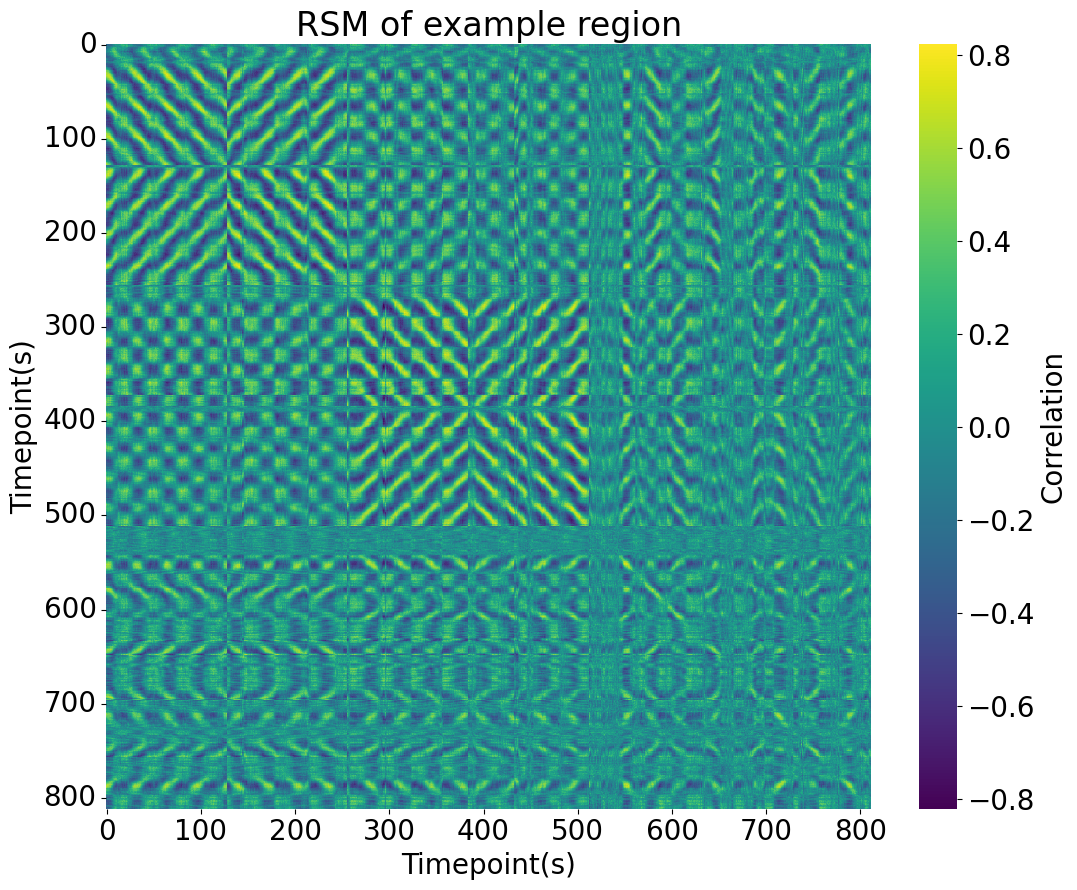

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# plot pixel RSM 
name = 'RSM of example region'
rsm = RSM[0][0] # 0-lv1, 1-lv2, 2-lv3, 3-lv4, 4-rv1, 5-rv2, 6-rv3, 7-rv4
vmin, vmax = -1, 1
n     = rsm.shape[0]
step  = 100
ticks = np.arange(0, n, step)
labels = ticks  # or ticks+1 if you want 1-based

# ** your font‐size control **
tick_fs   = 20  # <-- change this to whatever size you like
title_fs  = 24
label_fs  = 20
cbar_fs   = 20

plt.figure(figsize=(11, 9))
'''
ax = sns.heatmap(
    rsm, cmap='viridis',
    vmin=vmin,      # enforce same lower bound
    vmax=vmax,
    cbar_kws={'label': 'Correlation'}
)
'''
ax = sns.heatmap(
    rsm, cmap='viridis',
    cbar_kws={'label': 'Correlation'}
)

# center ticks on cells
ax.set_xticks(ticks + 0.5)
ax.set_yticks(ticks + 0.5)

# set tick labels and sizes
ax.set_xticklabels(labels, rotation=0, fontsize=tick_fs)
ax.set_yticklabels(labels, rotation=0, fontsize=tick_fs)

# also enforce via tick_params
ax.tick_params(axis='x', labelsize=tick_fs)
ax.tick_params(axis='y', labelsize=tick_fs)

# resize colorbar ticks & label
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=cbar_fs)
cbar.ax.set_ylabel('Correlation', fontsize=label_fs)

# titles & axis labels
ax.set_title(f"{name}", fontsize=title_fs)
ax.set_xlabel("Timepoint(s)", fontsize=label_fs)
ax.set_ylabel("Timepoint(s)", fontsize=label_fs)

plt.tight_layout()
plt.show()


## Statistics and plots of representational distance

In [385]:
# representational distance of each RSM anchored to stimuli representations of V1
# convert distances to z-transform for each region across subjects and then run statistics
all_results_left, all_results_right = all_results_distances[:, 0, 1:4], all_results_distances[:, 1, 5:]
names_left, names_right = ordered_names[1:4], ordered_names[5:]
z_vals_left = np.zeros((40, len(names_left)))
z_vals_right = np.zeros((40, len(names_right)))
for reg in range(len(names_left)):
    distances_here_left = all_results_left[:,reg]
    distances_here_right = all_results_right[:,reg]
    z_vals_left[:,reg] = RSA_functions.distances_to_fisher_z(distances_here_left)
    z_vals_right[:,reg] = RSA_functions.distances_to_fisher_z(distances_here_right)


In [61]:
# seperate hemispheres and remove V1 since it is the anchor
# Split metric and names into hemispheres

# statistics on communicability results
names = ['V2', 'V3', 'V4']
sig_pairs_left, all_stats_left = stats_functions.compute_pairwise_tstats(z_vals_left, names, alpha=0.05)
sig_pairs_right, all_stats_right = stats_functions.compute_pairwise_tstats(z_vals_right, names, alpha=0.05)


In [125]:
np.mean(all_results_right[:,2] - all_results_right[:,1])

0.16302322956253323

In [119]:
all_stats_right

[{'region1': 'V2',
  'region2': 'V3',
  'n': 40,
  'df': 39.0,
  't': 10.737279476165664,
  'p_raw': 3.285491614534879e-13,
  'p_bonf': 9.856474843604638e-13,
  'mean_diff': 0.2113276763827127,
  'ci_low': 0.17151772516363306,
  'ci_high': 0.2511376276017923,
  'cohen_dz': 1.6977129509231559},
 {'region1': 'V2',
  'region2': 'V4',
  'n': 40,
  'df': 39.0,
  't': 30.43784635537482,
  'p_raw': 8.620898050171989e-29,
  'p_bonf': 2.5862694150515968e-28,
  'mean_diff': 0.5241350538238442,
  'ci_low': 0.48930462588013846,
  'ci_high': 0.5589654817675499,
  'cohen_dz': 4.812646077661965},
 {'region1': 'V3',
  'region2': 'V4',
  'n': 40,
  'df': 39.0,
  't': 20.22567500368897,
  'p_raw': 2.7974289566374333e-22,
  'p_bonf': 8.3922868699123e-22,
  'mean_diff': 0.3128073774411315,
  'ci_low': 0.2815247309062056,
  'ci_high': 0.3440900239760574,
  'cohen_dz': 3.1979600112995814}]

/Users/alextz/plotting_functions.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, fontsize=base_fs, rotation=0)


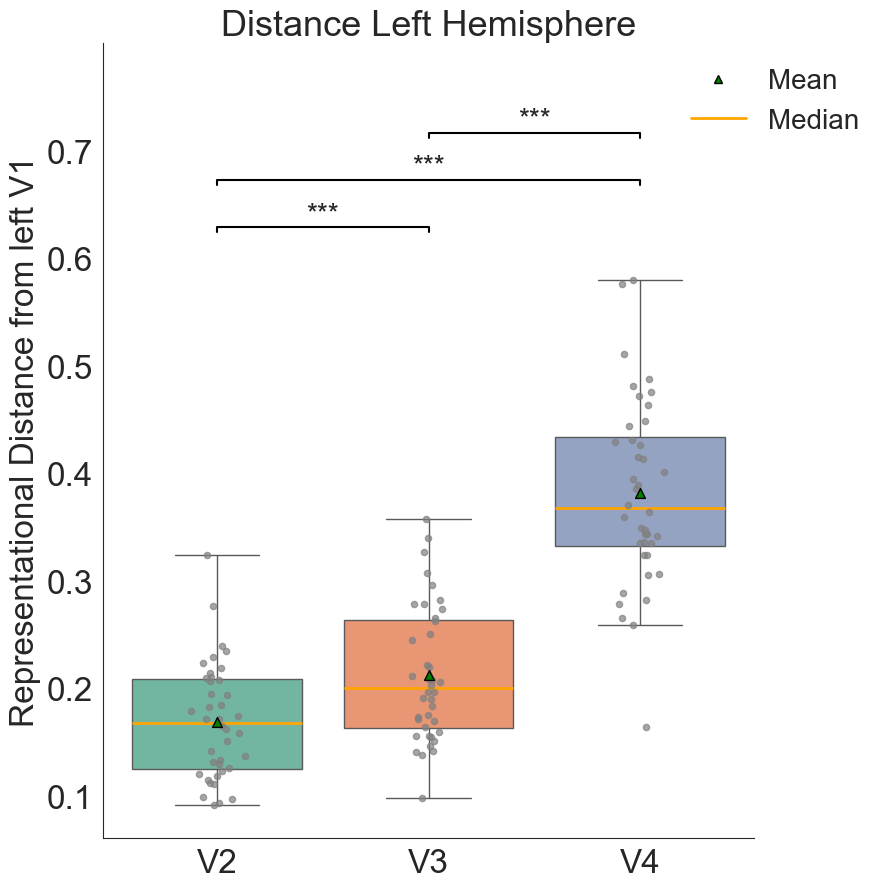

/Users/alextz/plotting_functions.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, fontsize=base_fs, rotation=0)


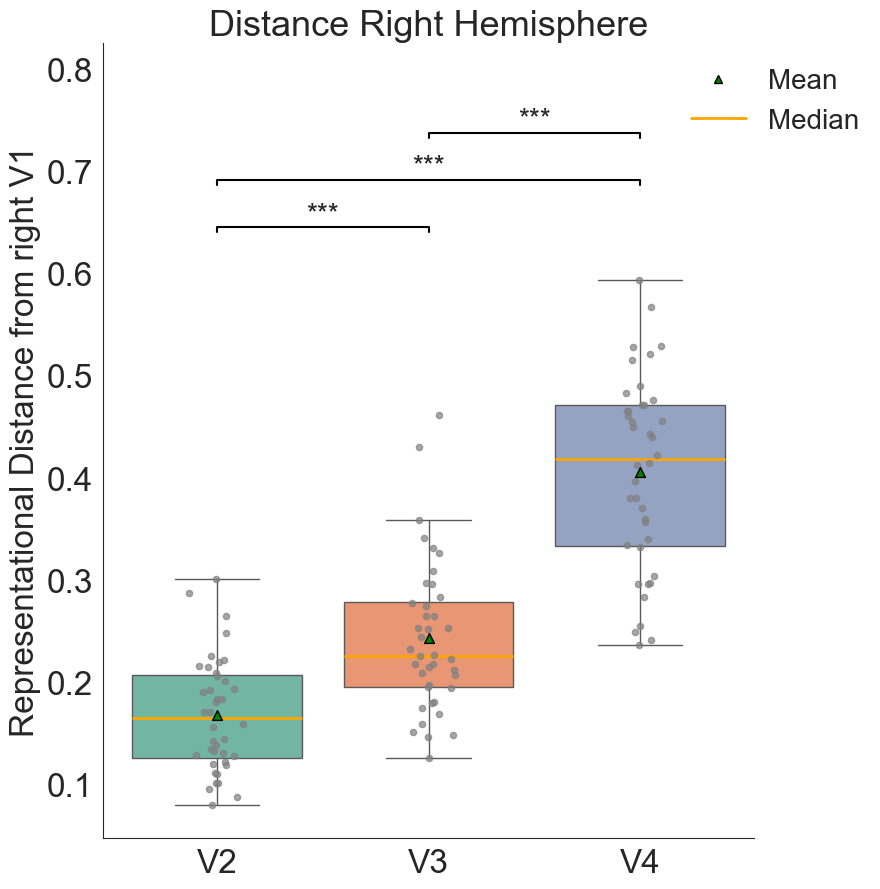

In [83]:
# box plots of results
names = ['V2', 'V3', 'V4']
sig_pairs_left, all_stats_left = stats_functions.compute_significant_pairs(z_vals_left, names, alpha=0.05)
sig_pairs_right, all_stats_right = stats_functions.compute_significant_pairs(z_vals_right, names, alpha=0.05)
plotting_functions.draw_hemisphere_boxplot(all_results_left,  r'Representational Distance from left V1', names,  'Distance Left Hemisphere', 
                                           save_path=None, figsize=(9,9), base_fs=24, sig_pairs=sig_pairs_left)

plotting_functions.draw_hemisphere_boxplot(all_results_right,  r'Representational Distance from right V1', names,  'Distance Right Hemisphere', 
                                           save_path=None, figsize=(9,9), base_fs=24, sig_pairs=sig_pairs_right)


# V1-initiated Empirical Neural Network


In [38]:
# run the model on original actflow
start_time = time.time()
steps = 6
sources = [1, 181] # 1-based parcel index: left and right V1, Glasser index

pc_folder = functions_dir
# lesion type can be: None (original), 'hier' (V2-V3, V3-V4, leading to the direct model), 'dir' (V1-V3, V1-V4, leading to the hierarchical model)
v1_pred_act_all, corr_all_subjects, r2_all_subjects = V1_initiated_model.run_model_parallel_across_subjects(data_all, subjects, steps, sources, 
                                                                                                            selected_parcels, dlabels, pc_folder,
                                                                                                            lesion_type=None, dilation=False, 
                                                                                                            threshold=None, LGN=False, 
                                                                                                            LGN_but_V1=False)
#Shape: (subjects, steps, runs, vertices, timepoints)

end_time = time.time()
total_time = end_time - start_time
print(f"Time it took for {steps} steps, = {total_time/60} minutes")


Time it took for 6 steps, = 0.34472631216049193 minutes


In [387]:
# load results from above
r2_all_subjects = np.load('enn_r2_all_40_subs_A_original.npy')
corr_all_subjects = np.load('enn_corr_all_40_subs_A_original.npy')
#Shape: (subjects, steps, runs, vertices, timepoints)

In [389]:
r2_all_subjects.shape

(40, 6, 6, 2565)

In [167]:
# compute R2 and corr at the parcel level, average r2,corr for each parcel, the unforgiving method
r2_avg_vert = np.zeros((40, 6, 6, 6)) # subs x steps x runs x parcels
corr_avg_vert = np.zeros((40, 6, 6, 6))
corr_all_subjects_z = np.arctanh(corr_all_subjects)
for sub in range(40):
    for step in range(6):
        for run in range(6):
            for parcel in range(6):
                indices_here = np.where(dlabels_subset_output == selected_parcels_output[parcel])[0]
                corr_here = corr_all_subjects_z[sub,step,run,indices_here]
                r2_here = r2_all_subjects[sub,step,run,indices_here]
                corr_avg_vert[sub,step,run,parcel] = np.mean(corr_here)
                r2_avg_vert[sub,step,run,parcel] = np.mean(r2_here)
r2_avg_vert_avg_subs_avg_runs = np.mean(r2_avg_vert, axis=(0,2)) # steps x parcels
corr_avg_vert_avg_subs_avg_runs_z = np.mean(corr_avg_vert, axis=(0,2))
corr_avg_vert_avg_subs_avg_runs = np.tanh(corr_avg_vert_avg_subs_avg_runs_z)

In [95]:
# compute R2 and corr at the parcel level, average ts for each parcel, the forgiving method, here average per step in order to plot
# run for 1 subject. In the next cell the results are loaded for the full group 
corr_parcels_1_sub, r2_parcels_1_sub = V1_initiated_model.model_comp_parcel_level(v1_pred_act_all, data_all, selected_parcels, dlabels)
# subs x steps x parcels


In [97]:
corr_parcels_1_sub.shape

(1, 6, 6)

In [391]:
# load corr and r2 parcel-level (based on averaging ts before calculating metrics)
# load the results from the above analysis but for all subjects
r2_parcels = np.load('r2_parcel_original_A.npy')
corr_parcels = np.load('corr_parcel_original_A.npy')
#Shape: (subjects, steps, parcels)

In [241]:
r2_parcels.shape

(40, 6, 6)

In [177]:
# results for the parcel-level based on averaging ts before calculating metrics
print(f"Corr = {np.mean(corr_parcels[:,5,:], axis=0)}")
print(f"R2 = {np.mean(r2_parcels[:,5,:], axis=0)}")

Corr = [0.84353234 0.80378684 0.67922652 0.85158747 0.81131921 0.64813249]
R2 = [0.5628913  0.45216661 0.26879963 0.54653667 0.43658048 0.20107392]


In [125]:
# results for the parcel-level method based on calculating metrics before averaging ts and then averaging metrics
print(f"R2 = {r2_avg_vert_avg_subs_avg_runs[5]*100}")
print(f"Corr = {corr_avg_vert_avg_subs_avg_runs[5]}")

R2 = [0.36659153 0.53497243 0.38461943 0.28623269 0.40264287 0.30224437]
Corr = [0.01202711 0.01630934 0.01310006 0.01132916 0.01453    0.01349608]


In [185]:
# run this function so that the next plot works correctly

def draw_model_steps_boxplot(
    r2_data,          # ndarray, shape (n_models, n_subjects, n_steps)
    model_names,      # list of str, length = n_models (1 or 2)
    step_names,       # list of str, length = n_steps
    p_corr_by_step=None,  # list of corrected p-values, length = n_steps (only for 2 models)
    metric_name='R²',
    title='Model Comparison Across Steps',
    box_to_anchor=(1.4, 1),
    showmeans=True,
    figsize=(12,6),
    base_fs=12,
    save_path=None
):
    """
    One plot: for each step, boxplots per model (1 or 2 models),
    with subject points and significance bracket per step if two models.
    """
    n_models, n_subj, n_steps = r2_data.shape
    assert n_models in (1, 2), "Only supports 1 or 2 models"
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.despine(ax=ax)

    xs = np.arange(n_steps)
    width = 0.3

    # Compute positions
    if n_models == 2:
        positions = [xs - width/2, xs + width/2]
    else:
        positions = [xs]  # single model

    # 1) Boxplots
    bps = []
    colors = ['C0', 'C1']
    for m in range(n_models):
        data_m = [r2_data[m, :, step] for step in range(n_steps)]
        pos = positions[m]
        bp = ax.boxplot(
            data_m,
            positions=pos,
            widths=width if n_models==2 else width*1.2,
            patch_artist=True,
            boxprops={'facecolor': colors[m], 'alpha': 0.6},
            showmeans=showmeans,
            medianprops={'color':'orange', 'linewidth':2},
            meanprops={'marker':'^','markerfacecolor':'green',
                       'markeredgecolor':'black','markersize':8},
            labels=None,
            showfliers=False
        )
        bps.append(bp)

    # 2) Overlay subject points
    for m in range(n_models):
        for step in range(n_steps):
            vals = r2_data[m, :, step]
            xpos = positions[m][step]
            jitter = width/8 if n_models==2 else width/4
            xs_jit = np.random.normal(loc=xpos, scale=jitter, size=n_subj)
            ax.scatter(xs_jit, vals, color='gray', alpha=0.7, s=20, zorder=3)

    # 3) Step labels + x-axis label
    ax.set_xticks(xs)
    ax.set_xticklabels(step_names, fontsize=base_fs)
    ax.set_xlabel('Steps', fontsize=base_fs)

    # 4) Legend (with ref-line entry)
    handles, labels = [], []

    # model patches only when >1 model
    if n_models == 2:
        handles.extend([
            Line2D([], [], marker='s', color='C0', linestyle='', label=model_names[0]),
            Line2D([], [], marker='s', color='C1', linestyle='', label=model_names[1])
        ])

    # always show median
    handles.append(Line2D([], [], color='orange', linewidth=2, label='Median'))

    if showmeans:
        handles.append(Line2D([], [], marker='^', color='green',
                              markeredgecolor='black', linestyle='', label='Mean'))    
    
    # extract labels and draw
    labels = [h.get_label() for h in handles]
    ax.legend(handles, labels,
              frameon=False,
              fontsize=base_fs-8,
              loc='upper right',
              bbox_to_anchor=box_to_anchor)

    # 5) Significance brackets per step (only for 2 models)
    if n_models == 2 and p_corr_by_step:
        y_min, y_max = np.nanmin(r2_data), np.nanmax(r2_data)
        yrange = y_max - y_min
        offset = 0.05 * yrange
        h = 0.02 * yrange

        for step, p_corr in enumerate(p_corr_by_step):
            if p_corr < 0.05:
                x1 = positions[0][step]
                x2 = positions[1][step]
                if p_corr < 0.001:
                    stars = '***'
                elif p_corr < 0.01:
                    stars = '**'
                else:
                    stars = '*'
                #y = y_max + offset * (step + 1)
                y = y_max + offset
                ax.plot([x1, x1, x2, x2],
                        [y, y+h, y+h, y],
                        lw=1.5, color='black')
                ax.text((x1+x2)/2, y+h, stars,
                        ha='center', va='bottom',
                        fontsize=base_fs-4)

        ax.set_ylim(top=y_max + offset*(n_steps+2))

    # 6) Labels and layout
    ax.set_title(title, fontsize=base_fs+1)
    ax.set_ylabel(metric_name, fontsize=base_fs)
    ax.tick_params(axis='y', labelsize=base_fs)
    
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

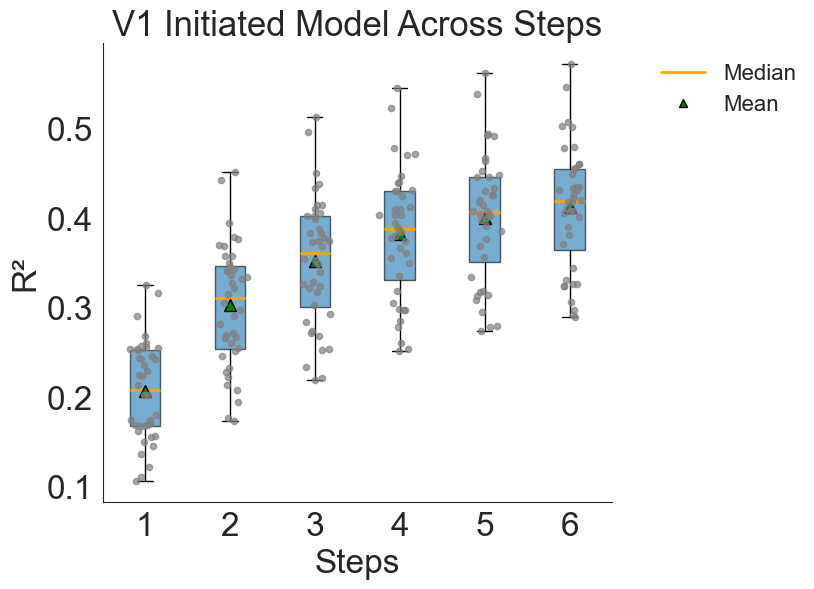

In [187]:
# create R2 box plots that show plateaue
step_names = [f'{i+1}' for i in range(6)]
r2_final_original_avg_parcels = np.mean(r2_parcels, axis=2) # subs x steps
r2_final = r2_final_original_avg_parcels[np.newaxis, :, :]    # bring it in the form that the function wants  
draw_model_steps_boxplot(
    r2_final,
    model_names=[],
    step_names=step_names,
    p_corr_by_step=None,
    title='V1 Initiated Model Across Steps',
    figsize=(9,6),
    base_fs=24,
    save_path=None
    )


# Permutations


In [227]:
# run 1 permutation for a single subject 
master_rng = np.random.RandomState(42)

# 2) Draw 1,000 independent integer seeds from it
seeds = master_rng.randint(0, 1_000_000_000, size=1)
steps = 6
sources = [1, 181]
null_model_r2_unforgiving = np.zeros((seeds.shape[0]))
null_model_r2_forgiving = np.zeros((seeds.shape[0]))
null_model_r2_vertex_wise = np.zeros((seeds.shape[0]))
for i,seed in enumerate(seeds):
    start_time = time.time()
    print('Running null model = ', i)
    FC_shuffle = np.zeros((num_subs, 4183, 4183))
    for sub in range(num_subs):
        fc = connectivity_matrix_all_subs[sub]
        FC_shuffle[sub] = graph_functions.generate_null_fc_zeros_in_place(fc, dlabels_subset, random_state=seed)
        
    v1_pred_act_all, corr_all_subjects, r2_all_subjects = V1_initiated_model.run_model_parallel_across_subjects(data_all, 
                                                                                                                subjects,
                                                                                                                steps,
                                                                                                                sources,
                                                                                                                selected_parcels, 
                                                                                                                dlabels,
                                                                                                                functions_dir,
                                                                                                                lesion_type=None,
                                                                                                                lesion_feedback=False,
                                                                                                                dilation=False, 
                                                                                                                threshold=None, 
                                                                                                                LGN=False, 
                                                                                                                LGN_but_V1=False, 
                                                                                                                FC_shuffle=FC_shuffle)
    #Shape: (subjects, steps, runs, vertices, timepoints)
    end_time = time.time()
    print(f'Time it took to run the model here = {(end_time - start_time)/60}')
        
    # forgiving method
    corr_final_original, r2_final_original = V1_initiated_model.model_comp_parcel_level(v1_pred_act_all, data_all, selected_parcels, dlabels)
    r2_final_original_last_step = r2_final_original[:,5,:] # extract last step
    r2_final_original_last_step_avg_subs = np.mean(r2_final_original_last_step, axis=0)
    null_model_r2_forgiving[i] = np.max(r2_final_original_last_step_avg_subs)
    
    # unforgiving method
    r2_avg_vert = np.zeros((num_subs, 6, 6, 6))
    for sub in range(num_subs):
        for step in range(6):
            for run in range(6):
                for parcel in range(6):
                    indices_here = np.where(dlabels_subset_output == selected_parcels_output[parcel])[0]
                    r2_here = r2_all_subjects[sub,step,run,indices_here]
                    r2_avg_vert[sub,step,run,parcel] = np.mean(r2_here)
    r2_avg_vert_avg_subs_avg_runs = np.mean(r2_avg_vert, axis=(0,2))
    r2_avg_vert_avg_subs_avg_runs_last_step = r2_avg_vert_avg_subs_avg_runs[5]
    null_model_r2_unforgiving[i] = np.max(r2_avg_vert_avg_subs_avg_runs_last_step)
    
    # vertex wise
    r2_all_subjects_avg_runs = np.mean(r2_all_subjects, axis=2)
    r2_all_subjects_avg_runs_last_step = r2_all_subjects_avg_runs[:,5,:] # extract last step
    r2_all_subjects_avg_runs_last_step_avg_subs = np.mean(r2_all_subjects_avg_runs_last_step, axis=0)
    null_model_r2_vertex_wise[i] = np.max(r2_all_subjects_avg_runs_last_step_avg_subs)
    
    end_time = time.time()
    print(f'Time it took for seed {i}, = {(end_time - start_time)/60}')
    

Running null model =  0
Time it took to run the model here = 0.3733673294385274
Time it took for seed 0, = 0.37656224966049195


In [235]:
null_model_r2_forgiving

array([0.38546535])

In [189]:
# load r2 based on 1000 permutations for all subjects 
r2_vertexwise = np.load('r2_vertexwise_permutations_A.npy')
r2_unforgiving = np.load('r2_unforgiving_permutations_A.npy')
r2_forgiving = np.load('r2_forgiving_permutations_A.npy')

In [191]:
# calculate p-values based on the above null distributions, vertex-wise
alpha = 0.05
null_dist_vertices = r2_vertexwise
r2_all_subjects_model_avg_runs = np.mean(r2_all_subjects, axis=2)
r2_all_subjects_model_avg_runs_last_step = r2_all_subjects_model_avg_runs[:, 5, :]
r2_all_subjects_model_avg_runs_last_step_avg_subs = np.mean(r2_all_subjects_model_avg_runs_last_step, axis=0)

significant_vertices = np.zeros((r2_all_subjects.shape[3]))
p_value = np.zeros((r2_all_subjects.shape[3]))
for vert in range(significant_vertices.shape[0]):
    count = 0
    for vert1 in range(len(null_dist_vertices)):
        if null_dist_vertices[vert1] >= r2_all_subjects_model_avg_runs_last_step_avg_subs[vert]:
            count += 1
    p_value[vert] = (1+count)/1001

for vert in range(significant_vertices.shape[0]):
    if p_value[vert] < alpha:
        significant_vertices[vert] = 1
        

In [199]:
# calculate p-values based on the above null distributions, parcel-wise, unforgiving method. 
alpha = 0.05
null_dist_parcels = r2_unforgiving
r2_all_subjects_model_avg_runs_last_step_avg_subs = r2_avg_vert_avg_subs_avg_runs[5]

significant_parcels = np.zeros((r2_all_subjects_model_avg_runs_last_step_avg_subs.shape[0]))
p_value = np.zeros((significant_parcels.shape[0]))
for parc in range(significant_parcels.shape[0]):
    count = 0
    for parc1 in range(len(null_dist_parcels)):
        if null_dist_parcels[parc1] >= r2_all_subjects_model_avg_runs_last_step_avg_subs[parc]:
            count += 1
    p_value[parc] = (1+count)/1001

for parc in range(significant_parcels.shape[0]):
    if p_value[parc] < alpha:
        significant_parcels[parc] = 1
        

In [203]:
p_value

array([0.000999, 0.000999, 0.000999, 0.000999, 0.000999, 0.000999])

In [11]:
np.mean(r2_unforgiving)

0.06479378788485664

# Hierarchical vs Direct

In [337]:
# same code as original v1-enn but we use the lesion variable
# this code can be run separately for 1 subject for each lesion model
# results from this code, namely the variable v1_pred_act_all_hier_les (respectively v1_pred_act_all_dir_les)
# for the direct lesions can be used in the next cell to calculate r2 and corr at the parcel level
start_time = time.time()
steps = 6
sources = [1, 181]
# lesion type can be: None (original v1-enn), 'hier' (V2-V3, V3-V4, leading to the direct model), 'dir' (V1-V3, V1-V4, leading to the hierarchical model)
v1_pred_act_all_hier_les, corr_all_subjects, r2_all_subjects = V1_initiated_model.run_model_parallel_across_subjects(data_all, subjects, steps, sources, 
                                                                                                            selected_parcels, dlabels, functions_dir,
                                                                                                            lesion_type='hier', dilation=False, 
                                                                                                            threshold=None, LGN=False, 
                                                                                                            LGN_but_V1=False)
#Shape: (subjects, steps, runs, vertices, timepoints)

end_time = time.time()
total_time = end_time - start_time
print(f"Time it took for {steps} steps, = {total_time/60} minutes")


Time it took for 6 steps, = 0.34408103227615355 minutes


In [ ]:
# compare the models statistically for 1 sub
corr_final_hier_les, r2_final_hier_les = V1_initiated_model.model_comp_parcel_level(v1_pred_act_all_hier_les, data_all, selected_parcels, dlabels)
corr_final_dir_les, r2_final_dir_les = V1_initiated_model.model_comp_parcel_level(v1_pred_act_all_dir_les, data_all, selected_parcels, dlabels)
corr_final_orig, r2_final_orig = V1_initiated_model.model_comp_parcel_level(v1_pred_act_all, data_all, selected_parcels, dlabels) # subs x steps x parcels

In [249]:
# load corr and r2 parcel-level (based on averaging ts before calculating metrics)
# for the 2 lesion experiments based on all subs
r2_parcels_hier_les = np.load('r2_parcel_hier_les_A.npy')
corr_parcels_hier_les = np.load('corr_parcel_hier_les_A.npy')
r2_parcels_dir_les = np.load('r2_parcel_dir_les_A.npy')
corr_parcels_dir_les = np.load('corr_parcel_dir_les_A.npy')
#Shape: (subjects, steps, parcels)

r2_final_dir_les_avg_parcels = np.mean(r2_parcels_dir_les, axis=2) # subs x steps
r2_final_hier_les_avg_parcels = np.mean(r2_parcels_hier_les, axis=2)


In [251]:
r2_final_dir_les_avg_parcels.shape

(40, 6)

In [253]:
r2_final_dir_les_avg_parcels_avg_subs = np.mean(r2_final_dir_les_avg_parcels, axis=0)
r2_final_hier_les_avg_parcels_avg_subs = np.mean(r2_final_hier_les_avg_parcels, axis=0)

In [259]:
r2_final_hier_les_avg_parcels_avg_subs

array([0.20656131, 0.25219321, 0.27163619, 0.27919511, 0.28271194,
       0.2842305 ])

In [261]:
r2_data = np.zeros((2, 40, r2_parcels_dir_les.shape[1]))
r2_data[0] = r2_final_dir_les_avg_parcels
r2_data[1] = r2_final_hier_les_avg_parcels


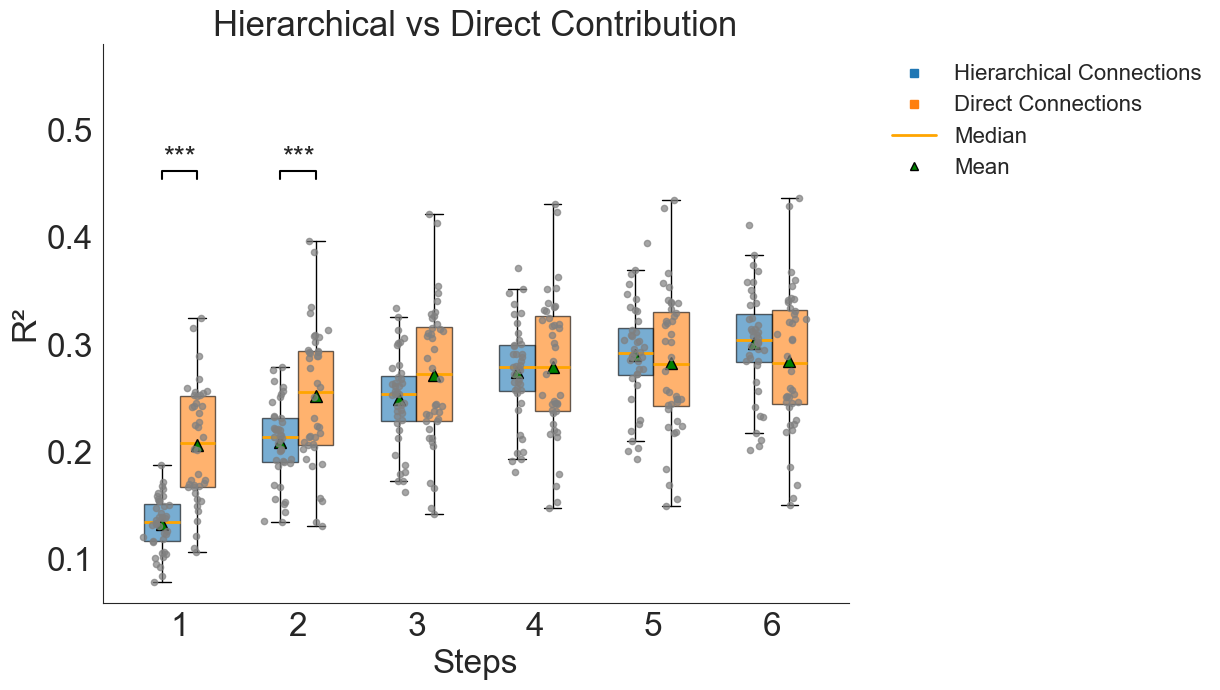

In [267]:

model_names = ['Hierarchical Connections', 'Direct Connections']
step_names = [f'{i+1}' for i in range(6)]
p_corr_by_step = compute_model_statistics_wilcoxon(r2_data, model_names)

draw_model_steps_boxplot(
    r2_data,
    model_names,
    step_names,
    p_corr_by_step,
    title='Hierarchical vs Direct Contribution',
    box_to_anchor=(1.5,1),
    figsize=(14,7),
    base_fs=24,
    save_path=None
)


# pRF-modeling

In [169]:
# load prf results for all subjects
with open("actual_ang_A.pkl", "rb") as f:
    actual_ang_all_subs = pickle.load(f)
with open("gen_ang_A.pkl", "rb") as f:
    gen_ang_all_subs = pickle.load(f)
with open("actual_ecc_A.pkl", "rb") as f:
    actual_ecc_all_subs = pickle.load(f)
with open("gen_ecc_A.pkl", "rb") as f:
    gen_ecc_all_subs = pickle.load(f)
with open("actual_rfs_A.pkl", "rb") as f:
    actual_rfs_all_subs = pickle.load(f)
with open("gen_rfs_A.pkl", "rb") as f:
    gen_rfs_all_subs = pickle.load(f)

In [309]:
# set this variable to any of the measurements above
# this will be used in the next cell to calculate correlation between actual and generated measurements
actual_prf_all_subs = actual_ang_all_subs
gen_prf_all_subs = gen_ang_all_subs

In [ ]:
# correlate actual and generated pRF measurements
parcels_output = [4, 5, 6, 184, 185, 186] 
corr_all_subs = np.zeros((40, len(parcels_output)))
angle = True
alpha = 0.05
for j in range(40):
    actual_here = actual_prf_all_subs[j]
    gen_here = gen_prf_all_subs[j]
    for i,par in enumerate(parcels_output):
        ind_here = np.where(dlabels==par)[0]
        actual_parcel_data = actual_here[ind_here]
        gen_parcel_data = gen_here[ind_here]
        valid = ~np.isnan(actual_parcel_data) & ~np.isnan(gen_parcel_data)
        print(f'Total vertices here = {len(ind_here)} , valid vertices here = {len(valid)}, percentage = {len(valid)/len(ind_here)}')
        if angle:
            actual = np.deg2rad(actual_parcel_data[valid])
            generated = np.deg2rad(gen_parcel_data[valid])
            corr_all_subs[j, i] = circcorrcoef(actual, generated)# for angle we need circular correlation
        else:
            x = actual_parcel_data[valid]
            y = gen_parcel_data[valid]
            stat_x, p_x = shapiro(x)
            stat_y, p_y = shapiro(y)
            if p_x > alpha and p_y > alpha:
                corr, pval = pearsonr(x, y)
            else:
                corr, pval = spearmanr(x, y)
                corr_all_subs[j, i] = corr

corr_all_subs_z = np.arctanh(corr_all_subs)
corr_mean_subs_z = np.mean(corr_all_subs_z, axis=0)
corr_mean_subs = np.tanh(corr_mean_subs_z)

In [315]:
corr_mean_subs

array([0.20931139, 0.25929105, 0.39674949, 0.27033613, 0.28865235,
       0.12040795])

In [481]:
# convert correlations to Fischer's z score and calculate statistics
corr_all_subs_z = np.arctanh(corr_all_subs)
t_stats, p_vals = ttest_1samp(corr_all_subs_z, popmean=0, axis=0)
reject, p_val, _, _ = multipletests(p_vals, alpha=0.05, method='bonferroni')


In [319]:
p_val

array([4.79728187e-04, 2.07550324e-04, 2.96079371e-05, 3.73608092e-04,
       1.59004693e-04, 5.84564807e-01])

/var/folders/8j/fy1y0bnj02vfsy3k2qvzjpyr0000gn/T/ipykernel_49820/2166337384.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, fontsize=base_fs, rotation=0)


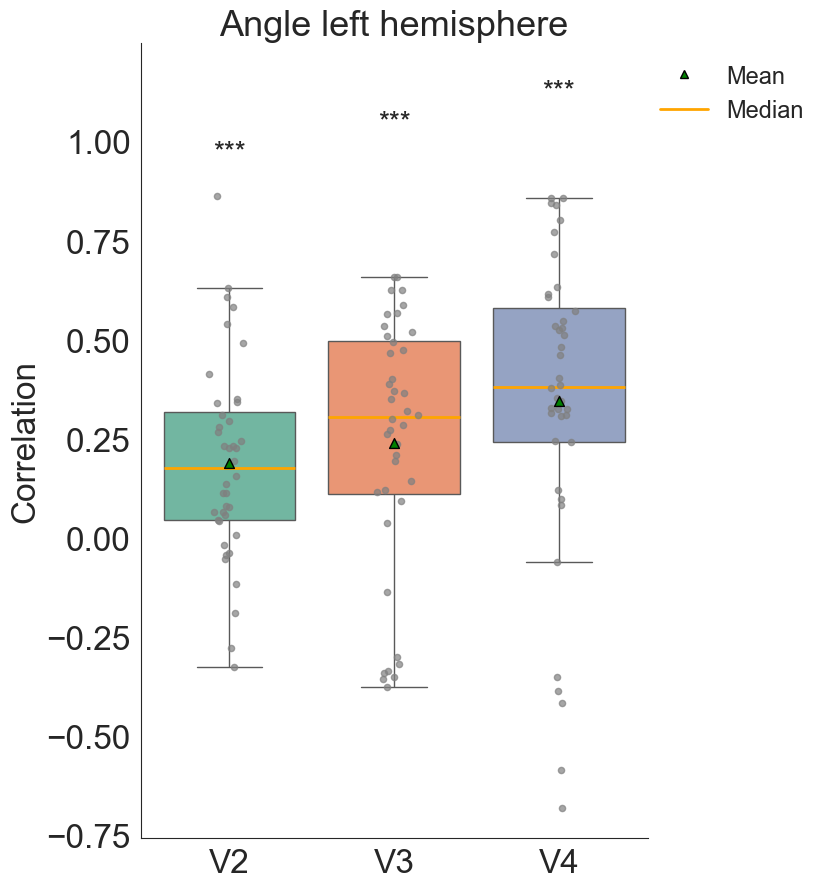

/var/folders/8j/fy1y0bnj02vfsy3k2qvzjpyr0000gn/T/ipykernel_49820/2166337384.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, fontsize=base_fs, rotation=0)


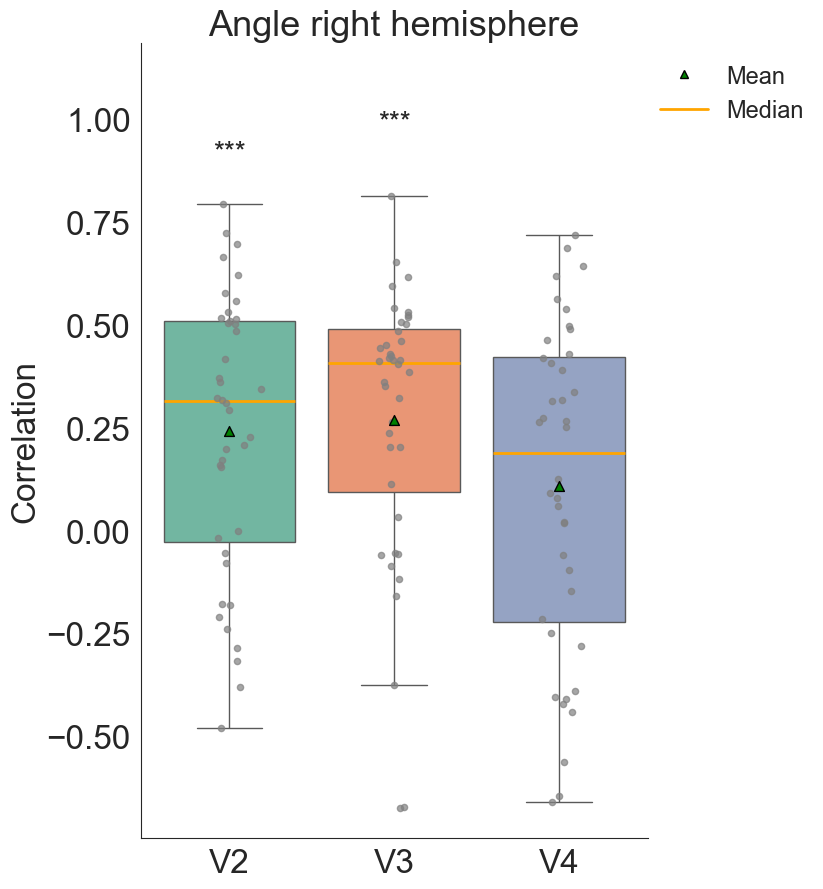

In [321]:
# plot the results
corr_left,  corr_right = corr_all_subs[:, :3], corr_all_subs[:, 3:]
names_left,      names_right     = ordered_names[:3],      ordered_names[3:]
names = ['V2', 'V3', 'V4']
sig_pairs_left = [
('V2', 'V2', p_val[0]),
('V3', 'V3', p_val[1]),   # one “*” over box L
('V4', 'V4', p_val[2])   # two “**” over box R
]
sig_pairs_right = [
('V2', 'V2', p_val[3]),
('V3', 'V3', p_val[4]),   # one “*” over box L
('V4', 'V4', p_val[5])   # two “**” over box R
]

draw_hemisphere_boxplot(corr_left,  'Correlation', names,  'Angle left hemisphere', 
                                           save_path=None, figsize=(9,9), base_fs=24, sig_pairs=sig_pairs_left)
draw_hemisphere_boxplot(corr_right, 'Correlation', names, 'Angle right hemisphere', 
                                           save_path=None, figsize=(9,9), base_fs=24, sig_pairs=sig_pairs_right)

# Dimensionality

In [71]:
# code to generate dimensionality for 1 sub. 
num_regions = len(selected_parcels)
dim_results_actual = np.zeros((num_subs, num_regions)) 

start_time = time.time()
for subj in range(num_subs):
    for reg in range(num_regions):
        rsm_here = RSM[subj][reg]
        dim_results_actual[subj, reg] = RSA_functions.getDimensionality(rsm_here)

end_time = time.time()
print(f"Time it took = {(end_time - start_time)/60} minutes")

Time it took = 0.04398560126622518 minutes


In [325]:
# based on the above, load dimensionality for all subjects
dim_results_actual = np.load('Dimensionality_actual_all_parcels_A.npy')


In [327]:
# statistics on dimensionality
names = ['V1', 'V2', 'V3', 'V4']
dim_results_actual_left = dim_results_actual[:,:4]
sig_pairs_left, all_stats_left = stats_functions.compute_significant_pairs(dim_results_actual_left, names, alpha=0.05)

dim_results_actual_right = dim_results_actual[:,4:]
sig_pairs_right, all_stats_right = stats_functions.compute_significant_pairs(dim_results_actual_right, names, alpha=0.05)


/var/folders/8j/fy1y0bnj02vfsy3k2qvzjpyr0000gn/T/ipykernel_49820/2166337384.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, fontsize=base_fs, rotation=0)


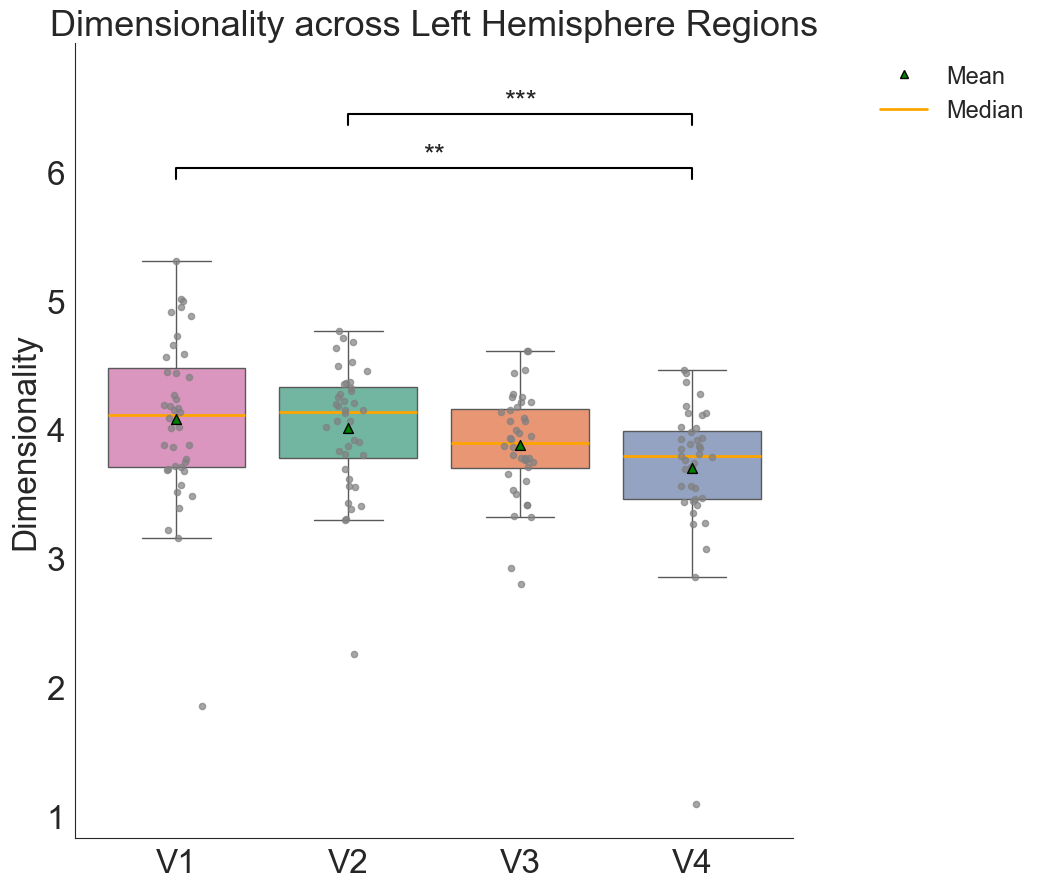

/var/folders/8j/fy1y0bnj02vfsy3k2qvzjpyr0000gn/T/ipykernel_49820/2166337384.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, fontsize=base_fs, rotation=0)


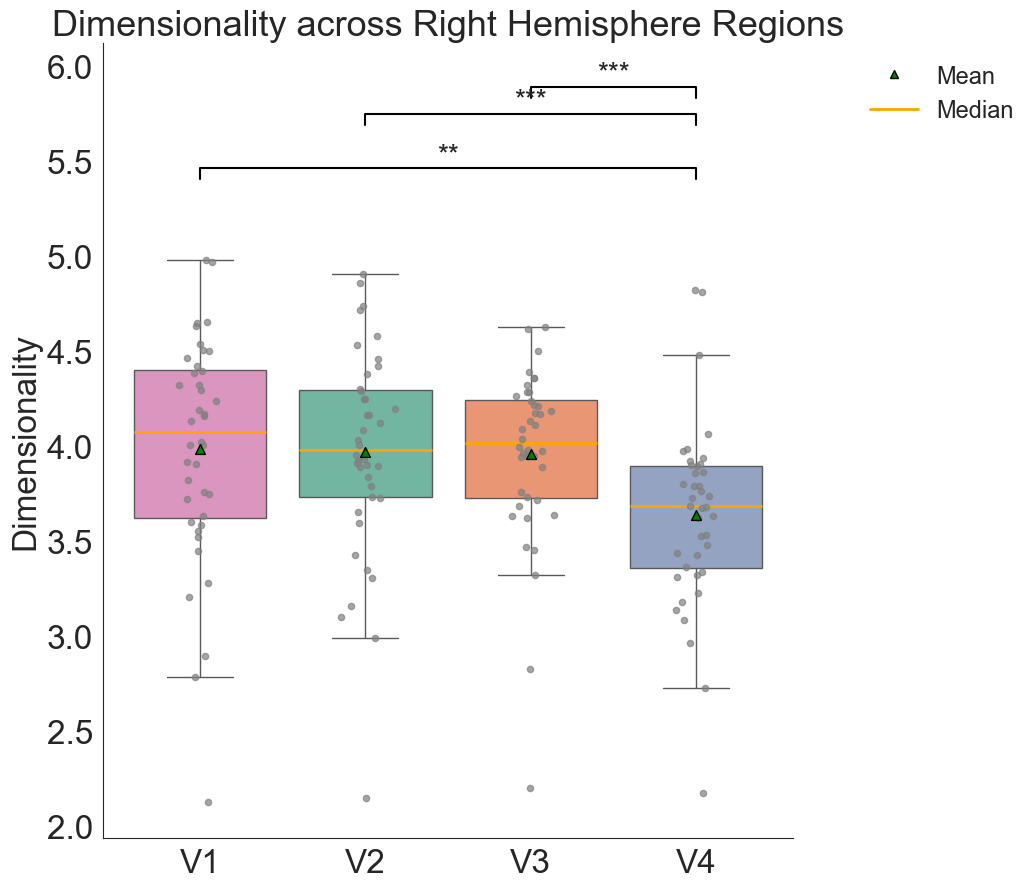

In [329]:
# box plots across subjects

# plot of actual dimensionalities, base this on previous plotting code where we plot for example communicability or something else
metric_name = 'Dimensionality'
title = 'Dimensionality across Left Hemisphere Regions'
draw_hemisphere_boxplot(
    dim_results_actual_left,           # ndarray of shape (n_subjects, n_regions)
    metric_name,      # y‐axis label (string)
    names,            # list of region names, length = n_regions
    title,            # plot title (string)
    save_path=None,   # filepath to save figure (or None)
    figsize=(11,9),  # figure size
    base_fs=24,       # base font size
    sig_pairs=sig_pairs_left,   # list of (region1, region2, p_val) or None
    showmeans=True
)

title = 'Dimensionality across Right Hemisphere Regions'
draw_hemisphere_boxplot(
    dim_results_actual_right,           # ndarray of shape (n_subjects, n_regions)
    metric_name,      # y‐axis label (string)
    names,            # list of region names, length = n_regions
    title,            # plot title (string)
    save_path=None,   # filepath to save figure (or None)
    figsize=(11,9),  # figure size
    base_fs=24,       # base font size
    sig_pairs=sig_pairs_right,   # list of (region1, region2, p_val) or None
    showmeans=True
)


## ActFlow dimensionality

In [343]:
# calculate RSM based on ENN model
# assumes ENN model has already been run for the single sub provided
# either load hier_les or dir_les by commenting out relevant line below
num_steps = v1_pred_act_all_dir_les.shape[1]
RSM_pred = np.zeros((num_subs, num_steps, len(regions_subset), 812, 812))
for subj in range(num_subs):
    print(f"Processing subject: {subj}")
    for step in range(num_steps):
        data_subj = v1_pred_act_all_dir_les[subj,step,:,:,:] # line to comment out
        #data_subj = v1_pred_act_all_hier_les[subj,step,:,:,:] # line to comment out depending on which model you wish to run
        all_regions_first_half, all_regions_second_half = RSA_functions.first_second_half_each_run(data_subj, regions_subset, T)
        for reg in range(len(regions_subset)):
            RSM_pred[subj][step][reg] = RSA_functions.cross_validated_rsm_via_corrcoef(all_regions_first_half[reg], all_regions_second_half[reg])  
        

Processing subject: 0


/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


In [345]:
#RSM_final_hier_les = RSM_pred
RSM_final_dir_les = RSM_pred

In [347]:
# calculate dimensionality for a single subject
num_regions = len(selected_parcels)
dim_results_dir_les = np.zeros((num_subs, 6, num_regions)) 
dim_results_hier_les = np.zeros((num_subs, 6, num_regions)) 

for subj in range(num_subs):
    for step in range(6):
        for reg in range(num_regions):
            rsm_here_dir_les = RSM_final_dir_les[subj][step][reg]
            rsm_here_hier_les = RSM_final_hier_les[subj][step][reg]
            dim_results_dir_les[subj, step, reg] = RSA_functions.getDimensionality(rsm_here_dir_les)
            dim_results_hier_les[subj, step, reg] = RSA_functions.getDimensionality(rsm_here_hier_les)


/Users/alextz/RSA_functions.py:28: RuntimeWarning: invalid value encountered in scalar divide
  dimensionality = (dimensionality_nom**2) / dimensionality_denom


In [127]:
# based on the above, load dimensionality for hierarchical and direct pathway lesion models for all subjects
dim_results_dir_les = np.load('dimensionality_pred_dir_les_A.npy')
dim_results_hier_les = np.load('dimensionality_pred_hier_les_A.npy')


In [139]:
# exlcude left and right v1
to_remove = [0, 4]     

dim_results_dir_les_final = np.delete(dim_results_dir_les, to_remove, axis=2)
dim_results_hier_les_final = np.delete(dim_results_hier_les, to_remove, axis=2)

dim_results_dir_les_final = np.nan_to_num(dim_results_dir_les_final, nan=0.0)
dim_results_hier_les_final = np.nan_to_num(dim_results_hier_les_final, nan=0.0)

# avg across subs, exclude 0s because they were nans
marr = np.ma.masked_equal(dim_results_dir_les_final, 0)
dim_results_dir_les_avg_parcels = marr.mean(axis=2)
marr = np.ma.masked_equal(dim_results_hier_les_final, 0)
dim_results_hier_les_avg_parcels = marr.mean(axis=2)

num_subs = 40
dim_data = np.zeros((2, num_subs, dim_results_dir_les_avg_parcels.shape[1]))
dim_data[0] = dim_results_dir_les_avg_parcels
dim_data[1] = dim_results_hier_les_avg_parcels

model_names = ['Hierarchical Connections', 'Direct Connections']
p_corr_by_step = compute_model_statistics_wilcoxon(dim_data, model_names)
step_results = compute_model_statistics_wilcoxon_with_r(
    dim_data,
    model_names,
    alpha=0.05,
    zero_method="wilcox",
    correction=False,
    alternative="two-sided",
    method="approx",
)

In [151]:
np.mean(dim_results_hier_les_avg_parcels[:,0] - dim_results_dir_les_avg_parcels[:,0])

0.06388422612653755

In [141]:
step_results

[{'model_a': 'Hierarchical Connections',
  'model_b': 'Direct Connections',
  'step': 0,
  'n_pairs_non_nan': 40,
  'N_used_for_r': 40,
  'W': 341.0,
  'z': -0.9274495143273387,
  'r_effect': -0.1466426440045678,
  'p_raw': 0.35369319267722144,
  'p_bonf': 1.0,
  'median_diff': -0.024307349085577856,
  'mean_diff': -0.06388422612653755,
  'alternative': 'two-sided',
  'zero_method': 'wilcox'},
 {'model_a': 'Hierarchical Connections',
  'model_b': 'Direct Connections',
  'step': 1,
  'n_pairs_non_nan': 40,
  'N_used_for_r': 40,
  'W': 73.0,
  'z': -4.529717193163958,
  'r_effect': -0.71621117434115,
  'p_raw': 5.906269087293469e-06,
  'p_bonf': 3.543761452376081e-05,
  'median_diff': -0.260939905008694,
  'mean_diff': -0.2737773810155583,
  'alternative': 'two-sided',
  'zero_method': 'wilcox'},
 {'model_a': 'Hierarchical Connections',
  'model_b': 'Direct Connections',
  'step': 2,
  'n_pairs_non_nan': 40,
  'N_used_for_r': 40,
  'W': 44.0,
  'z': -4.919514815127623,
  'r_effect': -0.7

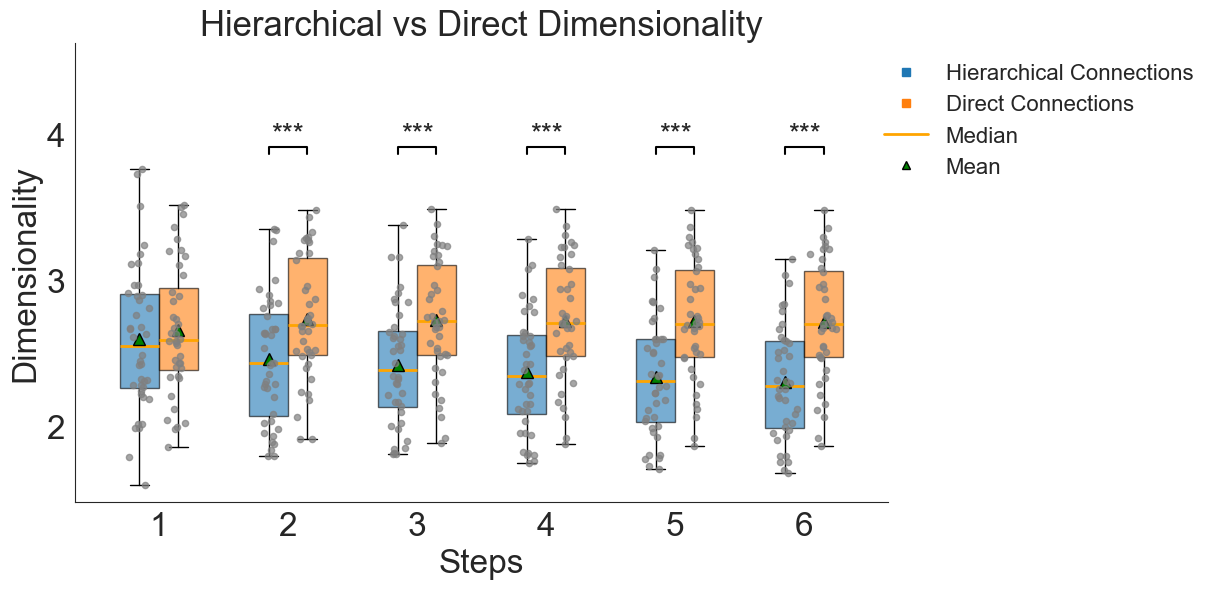

In [355]:
# plot the results
model_names = ['Hierarchical Connections', 'Direct Connections']
step_names = [f'{i+1}' for i in range(6)]
p_corr_by_step = compute_model_statistics_wilcoxon(dim_data, model_names)

draw_model_steps_boxplot(
    dim_data,
    model_names,
    step_names,
    p_corr_by_step,
    metric_name = 'Dimensionality',
    title='Hierarchical vs Direct Dimensionality',
    figsize=(13,6),
    base_fs=24,
    save_path=None
)


# Hierarchy & Periphery

## Deviation

In [301]:
# load actual, hierarchical and direct prf measurements
# calculate deviation from actual measurements for each model for each vertex 
# demonstrate that for direct pathway deviation increases as ecc/rfs increase
# demonstrate that for hierarchical pathway deviation decreases as ecc/rfs increase
all_results_gen_hier_all_subs = np.load('prf_hier_A.npy')
all_results_gen_dir_all_subs = np.load('prf_dir_A.npy')
all_results_actual_all_subs = np.load('prf_actual_A.npy')


In [307]:
import numpy as np
from scipy.stats import spearmanr, ttest_1samp, wilcoxon

def fisher_z(r, tiny=1e-8):
    r = np.clip(r, -1+tiny, 1-tiny)
    return np.arctanh(r)

def group_test(corrs, names, alt='greater', bonf_m=None, label=""):
    corrs = np.asarray(corrs, float)  # (n_subj, n_parcels)
    n_subj, n_parc = corrs.shape
    if bonf_m is None:
        bonf_m = n_parc

    z = fisher_z(corrs)
    mean_r = np.full(n_parc, np.nan)
    ci_lo  = np.full(n_parc, np.nan)
    ci_hi  = np.full(n_parc, np.nan)
    t_p    = np.full(n_parc, np.nan)
    w_p    = np.full(n_parc, np.nan)
    cohen_d = np.zeros(n_parcels)
    t_stat = np.zeros(n_parcels)

    for j in range(n_parc):
        xz = z[:, j][np.isfinite(z[:, j])]
        xr = corrs[:, j][np.isfinite(corrs[:, j])]
        if xz.size < 4:
            print("Error")
            continue
        mz = xz.mean()
        sd = xz.std(ddof=1)
        cohen_d[j] = mz/sd
        se = sd / np.sqrt(xz.size)
        mean_r[j] = np.tanh(mz)
        ci_lo[j]  = np.tanh(mz - 1.96*se)
        ci_hi[j]  = np.tanh(mz + 1.96*se)
        t_stat[j], t_p[j] = ttest_1samp(xz, 0.0, alternative=alt)
        try:
            w_p[j] = wilcoxon(xr, alternative=alt, zero_method='wilcox').pvalue
        except ValueError:
            w_p[j] = np.nan

    t_p_b = np.minimum(t_p * bonf_m, 1.0)
    w_p_b = np.minimum(w_p * bonf_m, 1.0)

    print(f"\n== {label} ==")
    for j, nm in enumerate(names):
        print(f"{nm:>4} | mean ρ={mean_r[j]: .3f} [{ci_lo[j]:.3f},{ci_hi[j]:.3f}] "
              f"| t p={t_p[j]:.3g} (bonf {t_p_b[j]:.3g}) "
              f"| Wilcoxon p={w_p[j]:.3g} (bonf {w_p_b[j]:.3g})")

    return dict(mean_r=mean_r, ci=(ci_lo, ci_hi), t_stat=t_stat, cohen_d=cohen_d, t_p=t_p, t_p_b=t_p_b, w_p=w_p, w_p_b=w_p_b)

parcels = [5,6,185,186]       # LV3, LV4, RV3, RV4
parcel_names = ["LV3","LV4","RV3","RV4"]
delta_log_eps = 0.05          # stabilizer for logs
n_subj = 40

# containers: (n_subj, n_parcels)
rho_ecc_abs = np.full((n_subj, len(parcels)), np.nan)   # ΔABS vs ecc
rho_ecc_log = np.full((n_subj, len(parcels)), np.nan)   # ΔLOG vs ecc
rho_size_abs = np.full((n_subj, len(parcels)), np.nan)  # ΔABS vs size
rho_size_log = np.full((n_subj, len(parcels)), np.nan)  # ΔLOG vs size

for p_idx, pid in enumerate(parcels):
    verts = np.where(dlabels_subset_output == pid)[0]
    for s in range(n_subj):
        # pull true/pred for ecc (1) and size (5)
        ecc_t = all_results_actual_all_subs[s, 1, verts]
        ecc_h = all_results_gen_hier_all_subs[s, 1, verts]
        ecc_d = all_results_gen_dir_all_subs[s,  1, verts]

        size_t = all_results_actual_all_subs[s, 5, verts]
        size_h = all_results_gen_hier_all_subs[s, 5, verts]
        size_d = all_results_gen_dir_all_subs[s,  5, verts]

        good_e = np.isfinite(ecc_t) & np.isfinite(ecc_h) & np.isfinite(ecc_d)
        good_s = np.isfinite(size_t) & np.isfinite(size_h) & np.isfinite(size_d)
        
        # ----- ECC -----
        if good_e.sum() == verts.shape[0]:
            # ΔABS / ΔLOG (dir - hier): positive ⇒ hierarchy better
            dabs = np.abs(ecc_d[good_e] - ecc_t[good_e]) - np.abs(ecc_h[good_e] - ecc_t[good_e])
            dlog = (np.abs(np.log(ecc_d[good_e] + delta_log_eps) - np.log(ecc_t[good_e] + delta_log_eps))
                    - np.abs(np.log(ecc_h[good_e] + delta_log_eps) - np.log(ecc_t[good_e] + delta_log_eps)))
            rho_ecc_abs[s, p_idx] = spearmanr(ecc_t[good_e], dabs).statistic
            rho_ecc_log[s, p_idx] = spearmanr(ecc_t[good_e], dlog).statistic
        else:
            print("Error")

        # ----- SIZE -----
        if good_s.sum() == verts.shape[0]:
            dabs = np.abs(size_d[good_s] - size_t[good_s]) - np.abs(size_h[good_s] - size_t[good_s])
            dlog = (np.abs(np.log(size_d[good_s] + delta_log_eps) - np.log(size_t[good_s] + delta_log_eps))
                    - np.abs(np.log(size_h[good_s] + delta_log_eps) - np.log(size_t[good_s] + delta_log_eps)))
            rho_size_abs[s, p_idx] = spearmanr(size_t[good_s], dabs).statistic
            rho_size_log[s, p_idx] = spearmanr(size_t[good_s], dlog).statistic
        else:
            print("Error")


# ----- Group tests (Bonferroni across 4 parcels, or 8 if you pool ecc+size) -----
m_corr = len(parcels)

dict1 = group_test(rho_ecc_abs, parcel_names, alt='greater', bonf_m=m_corr, label="ΔABS vs ECC (expect +)")
dict2 = group_test(rho_ecc_log, parcel_names, alt='greater', bonf_m=m_corr, label="ΔLOG vs ECC (expect +)")
dict3 = group_test(rho_size_abs, parcel_names, alt='greater', bonf_m=m_corr, label="ΔABS vs SIZE (expect +)")
dict4 = group_test(rho_size_log, parcel_names, alt='greater', bonf_m=m_corr, label="ΔLOG vs SIZE (expect +)")



== ΔABS vs ECC (expect +) ==
 LV3 | mean ρ= 0.176 [0.113,0.238] | t p=1.76e-06 (bonf 7.04e-06) | Wilcoxon p=1.9e-06 (bonf 7.62e-06)
 LV4 | mean ρ= 0.071 [0.011,0.131] | t p=0.0128 (bonf 0.0513) | Wilcoxon p=0.0129 (bonf 0.0518)
 RV3 | mean ρ= 0.098 [0.035,0.159] | t p=0.002 (bonf 0.008) | Wilcoxon p=0.00267 (bonf 0.0107)
 RV4 | mean ρ= 0.069 [0.013,0.124] | t p=0.00985 (bonf 0.0394) | Wilcoxon p=0.0204 (bonf 0.0816)

== ΔLOG vs ECC (expect +) ==
 LV3 | mean ρ= 0.188 [0.123,0.252] | t p=9.44e-07 (bonf 3.77e-06) | Wilcoxon p=4.35e-07 (bonf 1.74e-06)
 LV4 | mean ρ= 0.082 [0.016,0.147] | t p=0.00963 (bonf 0.0385) | Wilcoxon p=0.00794 (bonf 0.0318)
 RV3 | mean ρ= 0.139 [0.074,0.202] | t p=7.58e-05 (bonf 0.000303) | Wilcoxon p=9.67e-05 (bonf 0.000387)
 RV4 | mean ρ= 0.038 [-0.029,0.105] | t p=0.138 (bonf 0.552) | Wilcoxon p=0.17 (bonf 0.681)

== ΔABS vs SIZE (expect +) ==
 LV3 | mean ρ= 0.033 [-0.023,0.090] | t p=0.128 (bonf 0.512) | Wilcoxon p=0.264 (bonf 1)
 LV4 | mean ρ= 0.129 [0.057,0.1

In [311]:
dict4

{'mean_r': array([0.11837384, 0.21005314, 0.08518554, 0.14492286]),
 'ci': (array([0.05931189, 0.16025838, 0.04054104, 0.08983393]),
  array([0.17660991, 0.25878149, 0.12949059, 0.19912772])),
 't_stat': array([3.91446198, 8.10323422, 3.73348636, 5.11981525]),
 'cohen_d': array([0.61893078, 1.28123383, 0.59031603, 0.80951387]),
 't_p': array([1.76675731e-04, 3.44812550e-10, 3.01030044e-04, 4.28768698e-06]),
 't_p_b': array([7.06702923e-04, 1.37925020e-09, 1.20412018e-03, 1.71507479e-05]),
 'w_p': array([3.85437897e-05, 6.00448402e-09, 3.37733290e-04, 4.42399778e-06]),
 'w_p_b': array([1.54175159e-04, 2.40179361e-08, 1.35093316e-03, 1.76959911e-05])}

/var/folders/8j/fy1y0bnj02vfsy3k2qvzjpyr0000gn/T/ipykernel_49820/2166337384.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, fontsize=base_fs, rotation=0)


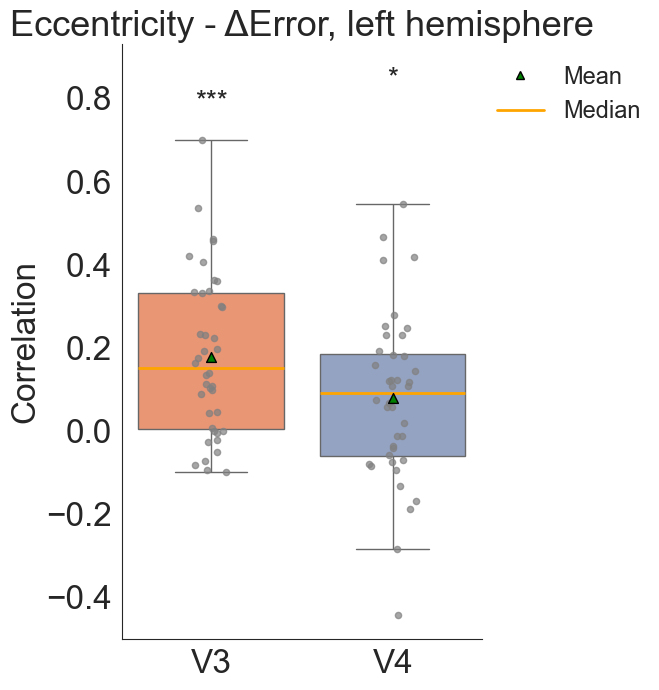

/var/folders/8j/fy1y0bnj02vfsy3k2qvzjpyr0000gn/T/ipykernel_49820/2166337384.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, fontsize=base_fs, rotation=0)


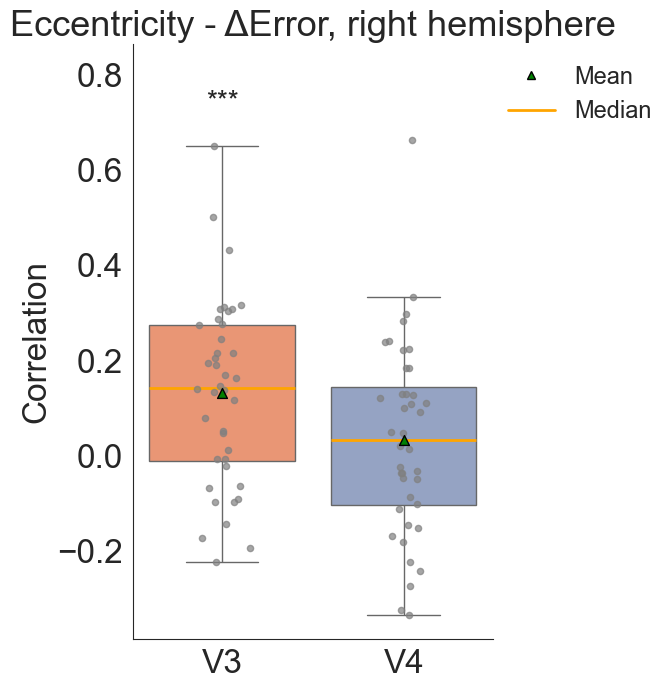

In [377]:
# create box plots for each parcel for each hemisphere
# draw_hemisphere_boxplot is taken from the code in the end for hier vs direct
# p values are obtained from the above cell 
# change the relevant line below to plot either eccentricity or rfs
names = ['V3', 'V4']
sig_pairs_left = [
('V3', 'V3', 0.000004),   
('V4', 'V4', 0.04)   
]
sig_pairs_right = [
('V3', 'V3', 0.0003),   
('V4', 'V4', 0.552)   
]
corr_left,  corr_right = rho_ecc_log[:, :2], rho_ecc_log[:, 2:] # line to be changed (commented out) p-values
# must also be updated based on the results above
#corr_left,  corr_right = rho_size_log[:, :2], rho_size_log[:, 2:]
draw_hemisphere_boxplot(corr_left,  'Correlation', names,  'Eccentricity - ΔError, left hemisphere', box_to_anchor=(1.5,1),
                                           save_path=None, figsize=(8,7), base_fs=24, sig_pairs=sig_pairs_left)
draw_hemisphere_boxplot(corr_right, 'Correlation', names, 'Eccentricity - ΔError, right hemisphere', box_to_anchor=(1.5,1),
                                           save_path=None, figsize=(8,7), base_fs=24, sig_pairs=sig_pairs_right)


## Hierarchy Index

In [ ]:
# load r2 of the lesion models

In [159]:
r2_all_subjects_dir_les = np.load('enn_r2_all_40_subs_A_dir_lesions.npy')
r2_all_subjects_hier_les = np.load('enn_r2_all_40_subs_A_hier_lesions.npy')

In [161]:

def hierarchy_index(r2_data_dir_les, r2_data_hier_les):
    '''
    r2_data_hier: r2 data for single sub for the last step, averaged across runs, all vertices included
    '''
    h_index = np.zeros((len(r2_data_hier_les)))
    for v in range(len(r2_data_hier_les)):
        h_index[v] = (r2_data_dir_les[v] - r2_data_hier_les[v])/(np.abs(r2_data_dir_les[v]) + np.abs(r2_data_hier_les[v]))
    
    return h_index


In [163]:
r2_all_subjects_dir_les.shape

(40, 6, 6, 2565)

In [165]:
r2_all_subjects_dir_les_avg_runs = np.mean(r2_all_subjects_dir_les, axis=2)
r2_all_subjects_hier_les_avg_runs = np.mean(r2_all_subjects_hier_les, axis=2)
r2_all_subjects_dir_les_avg_ecc_runs = np.mean(r2_all_subjects_dir_les[:,:,2:4,:], axis=2) # runs 2:4 are for ecc, 0:2 are for ang, 4: is rfs
r2_all_subjects_hier_les_avg_ecc_runs = np.mean(r2_all_subjects_hier_les[:,:,2:4,:], axis=2)
h_index_all_subs = np.zeros((40, r2_all_subjects_dir_les.shape[3]))
h_index_all_subs_ecc_runs = np.zeros((40, r2_all_subjects_dir_les.shape[3]))
for sub in range(40):
    r2_last_step_dir_les = r2_all_subjects_dir_les_avg_runs[sub,5,:]
    r2_last_step_hier_les = r2_all_subjects_hier_les_avg_runs[sub,5,:]
    r2_last_step_dir_les_ecc_runs = r2_all_subjects_dir_les_avg_ecc_runs[sub,5,:]
    r2_last_step_hier_les_ecc_runs = r2_all_subjects_hier_les_avg_ecc_runs[sub,5,:]
    h_index_all_subs[sub] = hierarchy_index(r2_last_step_dir_les, r2_last_step_hier_les)
    h_index_all_subs_ecc_runs[sub] = hierarchy_index(r2_last_step_dir_les_ecc_runs, r2_last_step_hier_les_ecc_runs)
    

In [285]:
actual_prf_all_subs = actual_rfs_all_subs
actual_prf_all_subs = actual_ecc_all_subs # change which measurement we will compare against

In [287]:
# correlate hierarchy index across subs for each parcel v3-v4
parcels_output_hierarchy = [5, 6, 185, 186] 
corr_all_subs_hier = np.zeros((40, len(parcels_output_hierarchy)))
alpha = 0.05
for j in range(40):
    actual_here = actual_prf_all_subs[j]
    for i,par in enumerate(parcels_output_hierarchy):
        ind_here = np.where(dlabels==par)[0]
        ind_here_subset_output = np.where(dlabels_subset_output==par)[0]
        actual_parcel_data = actual_here[ind_here]
        h_index_parcel = h_index_all_subs_ecc_runs[j, ind_here_subset_output] # include eccentricity runs or all runs
        #h_index_parcel = h_index_all_subs[j, ind_here_subset_output] # include eccentricity runs or all runs
        valid = ~np.isnan(actual_parcel_data)
        x = actual_parcel_data[valid]
        y = h_index_parcel[valid]
        stat_x, p_x = shapiro(x)
        stat_y, p_y = shapiro(y)
        if p_x > alpha and p_y > alpha:
            corr, pval = pearsonr(x, y)
            print("pearsons")
        else:
            corr, pval = spearmanr(x, y)
        corr_all_subs_hier[j, i] = corr

corr_all_subs_z = np.arctanh(corr_all_subs_hier)
corr_mean_subs_z = np.mean(corr_all_subs_z, axis=0)
corr_mean_subs = np.tanh(corr_mean_subs_z)


In [267]:
corr_all_subs_hier[0]

array([ 0.33588509,  0.18615956,  0.24190479, -0.03556217])

In [269]:
corr_all_subs_hier.shape

(40, 4)

In [289]:
corr_mean_subs

array([0.30634705, 0.32423025, 0.36788715, 0.23029492])

In [291]:
# t-test against 0 for correlations 

v3_v4 = [5,6,185,186] # left and right v3-v4
n_parcels = len(v3_v4)
corrs = corr_all_subs_z
t_stat = np.zeros((n_parcels))
t_p = np.zeros((n_parcels))
w_stat = np.zeros((n_parcels))
w_p = np.zeros((n_parcels))

n_eff   = np.zeros(n_parcels, dtype=int)
df      = np.zeros(n_parcels)
cohen_d = np.zeros(n_parcels)
ci_low  = np.zeros(n_parcels)
ci_high = np.zeros(n_parcels)

for j in range(n_parcels):
    x = corrs[:, j]
    n = x.size                            # NEW
    n_eff[j] = n                          # NEW
    df[j] = n - 1                         # NEW
    tres = ttest_1samp(x, 0.0, alternative='greater')
    #tres = ttest_1samp(x, 0.0)
    t_stat[j], t_p[j] = tres.statistic, tres.pvalue

    # NEW: Cohen's d for one-sample (mean diff / sample SD)
    m  = x.mean()
    sd = x.std(ddof=1)
    cohen_d[j] = m / sd

    # NEW: 95% CI for the mean (two-sided; standard reporting)
    se = sd / np.sqrt(n)
    tcrit = t.ppf(0.975, df[j])           # 95% two-sided => 0.975
    ci_low[j]  = m - tcrit * se
    ci_high[j] = m + tcrit * se
    try:
        wres = wilcoxon(x, alternative='greater', zero_method='wilcox', correction=False)
        #wres = wilcoxon(x, zero_method='wilcox', correction=False)
        w_stat[j], w_p[j] = wres.statistic, wres.pvalue
    except ValueError:
        w_stat[j], w_p[j] = np.nan, np.nan

# Bonferroni correction
t_p_bonf = np.minimum(t_p * n_parcels, 1.0)
w_p_bonf = np.minimum(w_p * n_parcels, 1.0)
    

In [297]:
cohen_d

array([1.16179707, 1.50137162, 1.61358122, 0.78823014])

In [277]:
t_p_bonf

array([2.66153493e-03, 1.65886920e-07, 3.32842686e-05, 2.22788913e-04])

In [299]:
t_stat

array([ 7.34784986,  9.49550787, 10.20518366,  4.98520514])

In [293]:
t_stat

array([ 7.34784986,  9.49550787, 10.20518366,  4.98520514])

/var/folders/8j/fy1y0bnj02vfsy3k2qvzjpyr0000gn/T/ipykernel_49820/2166337384.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, fontsize=base_fs, rotation=0)


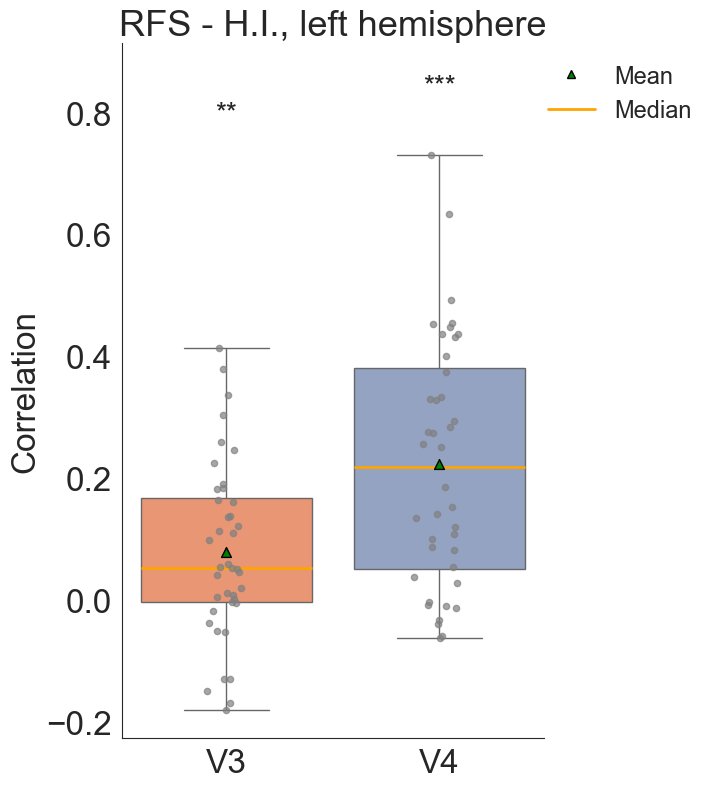

/var/folders/8j/fy1y0bnj02vfsy3k2qvzjpyr0000gn/T/ipykernel_49820/2166337384.py:277: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, fontsize=base_fs, rotation=0)


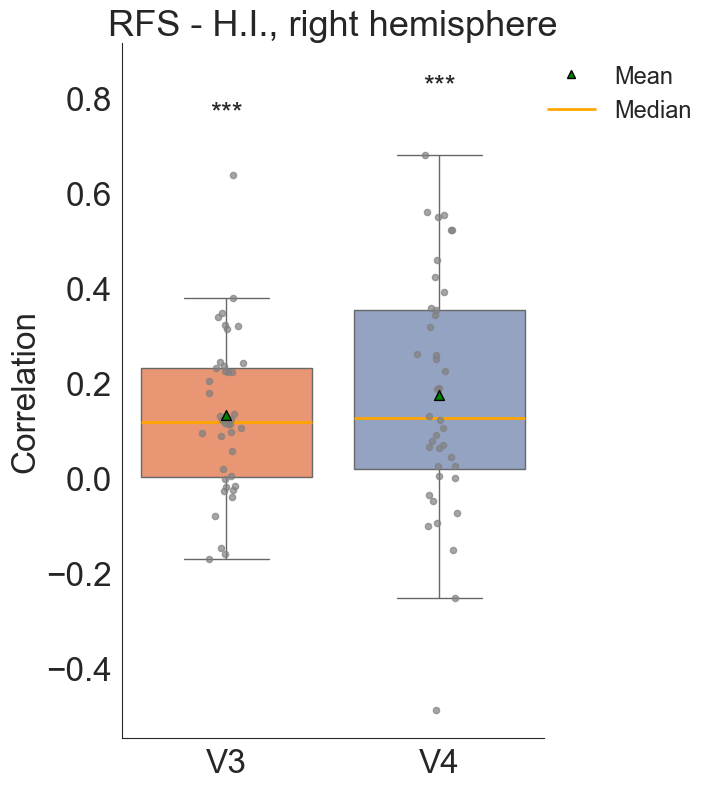

In [447]:
# create box plots for each parcel for each hemisphere
names = ['V3', 'V4']
sig_pairs_left = [
('V3', 'V3', 0.0027),   
('V4', 'V4', 0.0000001)   
]
sig_pairs_right = [
('V3', 'V3', 0.00006),   
('V4', 'V4', 0.0002)   
]
corr_left,  corr_right = corr_all_subs_hier[:, :2], corr_all_subs_hier[:, 2:]
draw_hemisphere_boxplot(corr_left,  'Correlation', names,  'RFS - H.I., left hemisphere',  box_to_anchor=(1.4,1),
                                           save_path=None, figsize=(8,8), base_fs=24, sig_pairs=sig_pairs_left)
draw_hemisphere_boxplot(corr_right, 'Correlation', names, 'RFS - H.I., right hemisphere',  box_to_anchor=(1.4,1),
                                           save_path=None, figsize=(8,8), base_fs=24, sig_pairs=sig_pairs_right)


# Supplement

## Dilation vs no Dilation
run actflow on dilated parcels

In [471]:
# same approach as original ENN but this time 5mm dilation has been applied
r2_final_original = np.load('r2_parcel_dilation_A.npy')

In [473]:
r2_final_original.shape

(15, 5, 6)

In [475]:
r2_final_original_avg_subs = np.mean(r2_final_original, axis=0)

In [477]:
r2_final_original_avg_subs

array([[0.33573645, 0.22552535, 0.1178386 , 0.30086176, 0.21270878,
        0.05155713],
       [0.39121942, 0.30445785, 0.18055215, 0.37885802, 0.30286231,
        0.11524061],
       [0.44138274, 0.34883639, 0.20833133, 0.42624216, 0.34739729,
        0.14135471],
       [0.45547869, 0.3723038 , 0.22597513, 0.44633809, 0.37409214,
        0.16235824],
       [0.46893421, 0.3856734 , 0.23419372, 0.46039016, 0.38910737,
        0.17239952]])

In [243]:
np.mean(r2_final_original_avg_subs[0,:])

0.20737134411482447

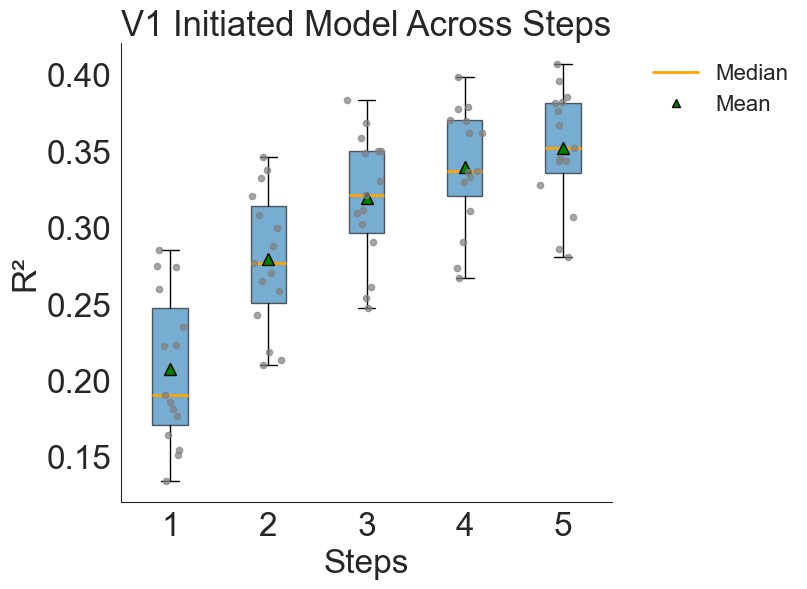

In [479]:
step_names = [f'{i+1}' for i in range(5)]
r2_final_original_avg_parcels = np.mean(r2_final_original, axis=2) # subs x steps
r2_final = r2_final_original_avg_parcels[np.newaxis, :, :]    # bring it in the form that the function wants  
draw_model_steps_boxplot(
    r2_final,
    model_names=[],
    step_names=step_names,
    p_corr_by_step=None,
    title='V1 Initiated Model Across Steps',
    figsize=(9,6),
    base_fs=24,
    save_path=None
    )